# Moneyball: A "Shallow-Dive" Into the World of Sabermetrics

This project investigates the relationships between various baseball metrics within the context of sabermetrics and their implications for player performance. Employing statistical methods such as correlation analysis and regression modeling, the study explores patterns and quantifies the influence of different metrics on player outcomes. The analysis includes exploratory data examination and regression models to predict player performance. Logistic regression is applied to evaluate the probability of championship outcomes based on team metrics. Results offer insights into the nuanced relationships between sabermetrics and player performance, providing valuable information for player evaluation and team optimization. The project showcases the application of statistical techniques in baseball analytics, contributing to a better understanding of the dynamic landscape of performance evaluation in the sport.

Table of contents
- Introduction
    - What is Moneyball?
    - Baseball Fundamentals
- Imports
    - Libraries and Visuals
    - The Data
    - Transforming and Merging
- Getting an Overview of the Data
- Modeling Simple Relationships With Linear Regression
    - For Batters
    - For Fielders
    - For Pitchers
- Using Multiple Regression to Attemt to Estimate Player Salary
- Determining Whether a Team Will Win the World Series or Not
- Conclusion
- Sources

### Introduction

##### What is Moneyball?

If you are unfamiliar, Moneyball is a book (Moneyball: The Art of Winning an Unfair Game, 2003) and a movie (2011) about the baseball team Oakland Athletics and their general manager, former professional baseball player Billy Beane, and their adoption of advanced statistics to assemble a winning team under strict budgetary constraints. It is based on the true story of how the Oakland A's encouraged a paradigm shift in the way baseball teams evaluate and choose their players and strategies. 

The story begins after an unsatisfactory season for the A's in 2001, the team is left in disarray after the departure of several key players during the post season. This leaves Beane to find replacements for the 2002 season which can hold up to the standard they expect for performance. But rather than following the outmoded counsel from his advisers (the old way of choosing players which was loosely based on the players' actual performance, with their appearance and behavior often being the deciding factors) he turned to statistics to construct a team that could compete in the big leagues with a budget of approximately 41 million USD (compared to other teams like the NY Yankees who had over 100 million USD to spend). 

Beane based his decisions heavily on the works by George William James, a baseball writer, historian, and statistician who devised an approach to determine why teams win and lose through statistical data and analyses, which he named sabermetrics (after the Society for American Baseball Research, SABR). With this unorthodox approach, Beane managed to create a team which did not only perform exceedingly well, but also kept the cost at a fraction of their competitors'. The team had a rocky start, and in turn they received plenty of criticism, but they proved their critics wrong after winning the division title (West) in the American league, and breaking the then record of 19 consecutive wins, with 20 wins in a row. 

Though the team did not live up to Beane's hope of winning the World Series, they accomplished something much bigger, the widespread adoption of advanced statistics (sabermetrics) in the world of baseball to optimize performance and spending. For example, after the Boston Red Sox took up the approach, they managed to win the World Series in 2004 after an 84-year dry spell. 

This term project will be focused on understanding some of the basics of sabermetrics by looking at historical data for teams and players, and performing some analyses with fundamental statistical techniques, and then interpreting the results. I will attempt to model relationships between the performance of a player or team, and appropriate statistics and metrics, and by doing so, hopefully get a deeper understanding of what makes a good player/team. I do, however realize that baseball is not a common sport in Norway, so to begin with, I will explain baseball to a level so that you can understand the process and results of my analyses (in the case that you are not already familiar with the sport). 

##### Baseball Fundamentals

Baseball is a ball-and-bat game, each game is played between two teams (home and visiting), one on offense (batting, running) and one on defense (pitching, fielding). The playing field (often referred to as a baseball diamond) originates on the ‘home plate’ extending outward at a 45-degree angle defining the fair and foul territories. The term ‘diamond’ comes from the shape formed by the four bases (plates), they are laid out as a square with home plate (or simply home) being the foundation, the other bases are: first, second, and third, arranged in the counterclockwise direction. The area these bases surround is called the infield with the pitcher’s mound (a raised circular area where the ball is pitched from) in the center, the outfield is everywhere else there is fair territory, the outfield is also usually bounded by a wall or fence, though over this bound is still fair territory. 

A game is played in nine ‘innings’, each inning is comprised of two half-innings (top and bottom for first and second half respectively) which denote which of the teams will be batting and which will be fielding. The visiting team always starts with batting at the top of each inning. Each half-inning is ended if three batters/runners are taken ‘out’ by the fielding team, and the teams switch roles. 

The game of baseball is a complex affair, but for this project you do not need to know all the ins and outs so I will only explain the basics, and throughout the project I will explain the more intricate aspects when they become relevant. The fielding team, and their pitcher starts by throwing the ball toward the batter on the opposing team, the batter tries to hit the ball into fair territory and when he manages that he runs to first base (or the one he can manage to run to; second, third, or all the way around the diamond; a home run). The fielding team wants to get ahold of the ball so they can take the runner ‘out’ before he reaches a base plate. Outs can come from several sources, if the batter does not manage to hit the ball after three pitches, he is out, if a fielder can get the ball to first base (or another base the batter is running to) before the batter gets there, he is out, if a fielder manages to catch the ball before it hits the ground, the batter is out, three outs and the half-inning is over. The goal of the offensive team is to get as many ‘runs’ as possible, a run occurs when a runner returns safely home after running through all bases, either as a home run or multiple runs from base to base as the next batters hit. The team with the most total runs after all nine innings are over, wins. On the occasion of a tie, a new inning is added until there is a winner.

Major League Baseball (MLB) is split into two separate leagues: The National League, and the American League, each with 15 teams participating. These are again subdivided into divisions: East, Central, and West (based on the geographical location of the team). As an example, the Oakland Athletics baseball team plays in the American league, in the West division (as their location is Oakland, California). A season in baseball usually consists of 162 games for each team, the teams who are the best in each of their respective divisions earns a division title. The teams with the best records in both leagues move on to the playoffs, here every qualified team plays through a series of additional tournaments which culminates in the World Series (poorly named as it only includes the US and Canada), which decides the very best team of the season. In this project, for simplicity, I will limit my data to teams who have played or is playing in Major League Baseball, thereby excluding other leagues like the American Association and Union Association who are also included in the datasets I will use, and other countries’ baseball leagues.

### Imports

##### Libraries and Visuals

In [1]:
# LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy.stats as spt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns

In [2]:
# VISUALS
# Figure size
plt.rcParams['figure.figsize'] = [16,10]

# Text sizes
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['axes.labelsize']= 12
plt.rcParams['font.size'] = 14

# Colors
plt.rcParams['legend.labelcolor'] = '#000000'
plt.rcParams['xtick.labelcolor'] = '#000000'
plt.rcParams['ytick.labelcolor'] = '#000000'
plt.rcParams['axes.labelcolor'] = '#000000'
plt.rcParams['axes.titlecolor'] = '#000000'
plt.rcParams['axes.edgecolor'] = '#000000'
plt.rcParams['xtick.color'] = '#000000'
plt.rcParams['ytick.color'] = '#000000'
plt.rcParams['figure.facecolor'] = '#ffffff'
plt.rcParams['axes.facecolor'] = '#ffffff'

# Graph colors
from cycler import cycler

diverse = ['#1f78b4', '#33a02c', '#e31a1c', '#ff7f00', '#6a3d9a', '#b15928', '#a6cee3', '#b2df8a', '#fb9a99']
greens = ['#2ca02c', '#4daf4a', '#45a05a', '#60bd68', '#5cb85c', '#6ba981', '#75bb6f', '#6dae64', '#4c9a5f']
blues = ['#1f78b4', '#377eb8', '#3182bd', '#4292c6', '#5aaed6', '#6baed6', '#7ba3df', '#92b3e4', '#a6bddb']
reds = ['#e41a1c', '#d73027', '#a50026', '#f46d43', '#d73027', '#fdae61', '#fee08b', '#fee08b', '#d73027']

plt.rcParams['axes.prop_cycle'] = cycler(color = diverse)

# Display max columns, pandas dataframes
pd.set_option('display.max_columns', None)

##### The Data

The data has been taken from the Lahman Baseball Database (assembled by Sean Lahman), which is a collection of historical baseball datasets dating back to 1871. The database has figures on several aspects of baseball, it has everything from information on how each individual player performed every year they played (whether they were batting, pitching, or fielding), to what the results of each season was and how each team performed that season. It also includes a lot of information I am not going to take advantage of for this project like college baseball, and what managers managed what teams in what season. I found a cleaned version (more consistent column names, less NaN values, etc.) of the database on Kaggle [1] which had data up to 2015, and I imported the most relevant datasets from the database.

I have also included a dataset including historical CPI (Consumer Price Index) data in the US so I can adjust player's salaries for inflation. I found this dataset on Kaggle as well [2].

The datasets I am importing are:
- batting.csv: Has figures on each players batting performance for every year they played.
- fielding.csv: Has figures on each players fielding performance for every year they played.
- pitching.csv: Has figures on each players pitching performance for every year they played.
- player.csv: Has information on each player's birth year, weight, height, and what their dominant hand is.
- salary.csv: Has each player's salary from each season and team they played for, not adjusted for inflation.
- team.csv: Has figures on how each team performed every year they played.
- cpi.csv: Has historical CPI values for the US.

Since I am using so many datasets, I will explain the different variables when they become relevant, rather than explaining them here.

In [3]:
# Limiting what columns are inluded to only get the relevant information.
batting = pd.read_csv('Data/batting.csv', 
                      usecols = ['player_id', 'year', 'stint', 'team_id', 'league_id', 
                                 'g', 'ab', 'r', 'h', 'double', 'triple', 'hr', 'rbi', 
                                 'sb', 'cs', 'bb', 'so', 'hbp', 'sh', 'sf'])
fielding = pd.read_csv('Data/fielding.csv', 
                       usecols = ['player_id', 'year', 'stint', 'team_id', 'league_id', 
                                  'pos', 'g', 'po', 'a', 'e', 'dp'])
pitching = pd.read_csv('Data/pitching.csv', 
                       usecols = ['player_id', 'year', 'stint', 'team_id', 'league_id', 
                                  'w', 'l', 'g', 'sho', 'sv', 'ipouts', 'h', 'er', 'hr', 
                                  'bb', 'so', 'era', 'hbp', 'bk', 'bfp'])
player = pd.read_csv('Data/player.csv', 
                     usecols = ['player_id', 'birth_year', 'name_first', 'name_last', 
                                'weight', 'height', 'bats', 'throws'])
salary = pd.read_csv('Data/salary.csv', 
                     usecols = ['year', 'player_id', 'team_id', 'league_id', 'salary'])
team = pd.read_csv('Data/team.csv', 
                   usecols = ['year', 'league_id', 'team_id', 'franchise_id', 'div_id', 
                              'rank', 'g', 'w', 'l', 'div_win', 'wc_win', 'lg_win', 
                              'ws_win', 'r', 'ab', 'h', 'double', 'triple', 'hr', 'bb', 
                              'so', 'sb', 'cs', 'hbp', 'sf', 'era', 'sho', 'sv', 
                              'ipouts', 'e'])
cpi = pd.read_csv('Data/cpi.csv')

As you can see, I have limited the data by choosing what columns I want to be included in the datasets, to see what features I have omitted please refer to documentation of the database: <a href = 'https://cran.r-project.org/web/packages/Lahman/Lahman.pdf'>here</a>. Some further limitations I will implement include: Only using data from the Major League (American and National League), as mentioned in the introduction. For that reason, I will also only be using data from 1876 to 2015 because neither the National or American League existed before then. 

In [4]:
# Limiting data to 1876-2015 and to leagues NL and AL:
batting = batting[(batting['year'] >= 1876) & (batting['league_id'].isin(['NL', 'AL']))]
fielding = fielding[(fielding['year'] >= 1876) & (fielding['league_id'].isin(['NL', 'AL']))]
pitching = pitching[(pitching['year'] >= 1876) & (pitching['league_id'].isin(['NL', 'AL']))]
team = team[(team['year'] >= 1876) & (team['league_id'].isin(['NL', 'AL']))]

##### Transforming and Merging

In [5]:
# Converting lbs to kg and inches to m, rounding to nearest integer.
player['weight'] = (player['weight'] * 0.453592).round()
player['height'] = (player['height'] * 2.54).round() / 100

Based on this I will calculate the BMI (Body Mass Index) for each player as I will use this as a feature in regression models. Although BMI is generally not a good measure for whether someone is overweight, it might be a good predictor for a baseball players performance. I am doing this with the assumption that the players had the same weight and height all throughout their careers. BMI is calculated by: 

$BMI = \frac{weight}{height^2}$, where weight is in kilograms and height is in meters.

In [6]:
player['bmi'] = (player['weight'] / (player['height'] ** 2)).round(1)

To adjust salaries for inflation using CPI I use this formula:

$Adjusted\ Salary = \frac{Nominal\ Salary}{CPI\ For\ Ending\ Year} \cdot CPI\ For\ Base\ Year$

I do this so I can analyze and compare the salaries for players over the years. An important note is that the data only has salary information from 1985 to 2015, so the data is limited. 

In [7]:
# Calculate the yearly CPI:
cpi['cpi'] = cpi[['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                  'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']].mean(axis = 1)

# Limit the CPI information to the appropriate years:
cpi = cpi[(cpi['Year'] >= 1985) & (cpi['Year'] <= 2015)]

# The year column in the CPI dataset was a float, correcting:
cpi['Year'] = cpi['Year'].astype(int)

# Renaming the column name for easier merging:
cpi = cpi.rename({'Year': 'year'}, axis = 1)

# Merging the CPI information with the salary dataset:
salary = pd.merge(salary, cpi[['year', 'cpi']], on = 'year', how = 'inner')

# Calculating the inflation adjusted salary based on the formula above:
salary['adj_salary'] = (salary['salary'] / salary['cpi']) * salary.loc[salary['year'] == 2015, 'cpi'].values[0]
salary.head()

,year,team_id,league_id,player_id,salary,cpi,adj_salary
0,1985,ATL,NL,barkele01,870000,107.566667,1.916995e+06
1,1985,ATL,NL,bedrost01,550000,107.566667,1.211894e+06
2,1985,ATL,NL,benedbr01,545000,107.566667,1.200876e+06
3,1985,ATL,NL,campri01,633333,107.566667,1.395513e+06
4,1985,ATL,NL,ceronri01,625000,107.566667,1.377152e+06


By checking with an inflation calculator, I can confirm that the adjusted salary is correct with some small error, I will ignore the error and say that this adjusted salary can be used to compare over time.

I will now merge the appropriate information from the salary (adjusted salary) and player (birth year, weight, height, bmi, bats, and throws) datasets into the batting, fielding, and pitching datasets. Using the **merge** function from pandas I can easily combine the data based on the necessary features. For the salary I will use year, player_id, and team_id to correctly assign the salary to the corresponding player in the right year when they played for the team that paid that salary. For the information from the player dataset I will simply use player_id to correctly assign the data to the corresponding player. 

In [8]:
# Adding the pertinent information to the batting dataset:
batting = pd.merge(batting, 
                   salary[['year', 'player_id', 'team_id', 'adj_salary']], 
                   on=['year', 'player_id', 'team_id'], how='left')
batting = pd.merge(batting, 
                   player[['player_id', 'weight', 'height', 'bmi', 'bats', 
                           'throws', 'birth_year']], on=['player_id'], how='left')

# Adding the pertinent information to the fielding dataset:
fielding = pd.merge(fielding, 
                    salary[['year', 'player_id', 'team_id', 'adj_salary']], 
                    on=['year', 'player_id', 'team_id'], how='left')
fielding = pd.merge(fielding, 
                    player[['player_id', 'weight', 'height', 'bmi', 'bats', 
                            'throws', 'birth_year']], on=['player_id'], how='left')

# Adding the pertinent information to the pitching dataset:
pitching = pd.merge(pitching, 
                    salary[['year', 'player_id', 'team_id', 'adj_salary']], 
                    on=['year', 'player_id', 'team_id'], how='left')
pitching = pd.merge(pitching, 
                    player[['player_id', 'weight', 'height', 'bmi', 'bats', 
                            'throws', 'birth_year']], on=['player_id'], how='left')

Now that I have the information about birth year in every dataset, I can calculate the age of each player for every year they played. I am not considering the time of year each player was born, so the age for some of the players might not be completely accurate, but the effect will be the same as they are consistently incorrect.

In [9]:
batting['age'] = batting['year'] - batting['birth_year']
fielding['age'] = fielding['year'] - fielding['birth_year']
pitching['age'] = pitching['year'] - pitching['birth_year']

In [10]:
wr_batting = batting.loc[batting['age'] < 0]['player_id'].tolist()
wr_fielding = fielding.loc[fielding['age'] < 0]['player_id'].tolist()
wr_pitching = pitching.loc[pitching['age'] < 0]['player_id'].tolist()
print('Wrongly assigned player in batting', wr_batting)
print('Wrongly assigned player in fielding', wr_fielding)
print('Wrongly assigned player in pitching', wr_pitching)

Wrongly assigned player in batting ['johnsbi01', 'johnsbi01']
Wrongly assigned player in fielding ['johnsbi01', 'johnsbi01']
Wrongly assigned player in pitching []


As you can see there is a player whose birth year was wrongly assigned based on his player id (to the batting and fielding datasets), so his age has become negative, I can easily remove this from the datasets like below. This does however imply that there might be multiple players whose information has been added wrong because the player ids are not completely accurate every time. I will check this by looking at a histogram, and the min and max values after I have removed the negative ages.

In [11]:
batting = batting[(batting['age'] > 0) | (batting['age'].isna())]
fielding = fielding[(fielding['age'] > 0) | (fielding['age'].isna())]

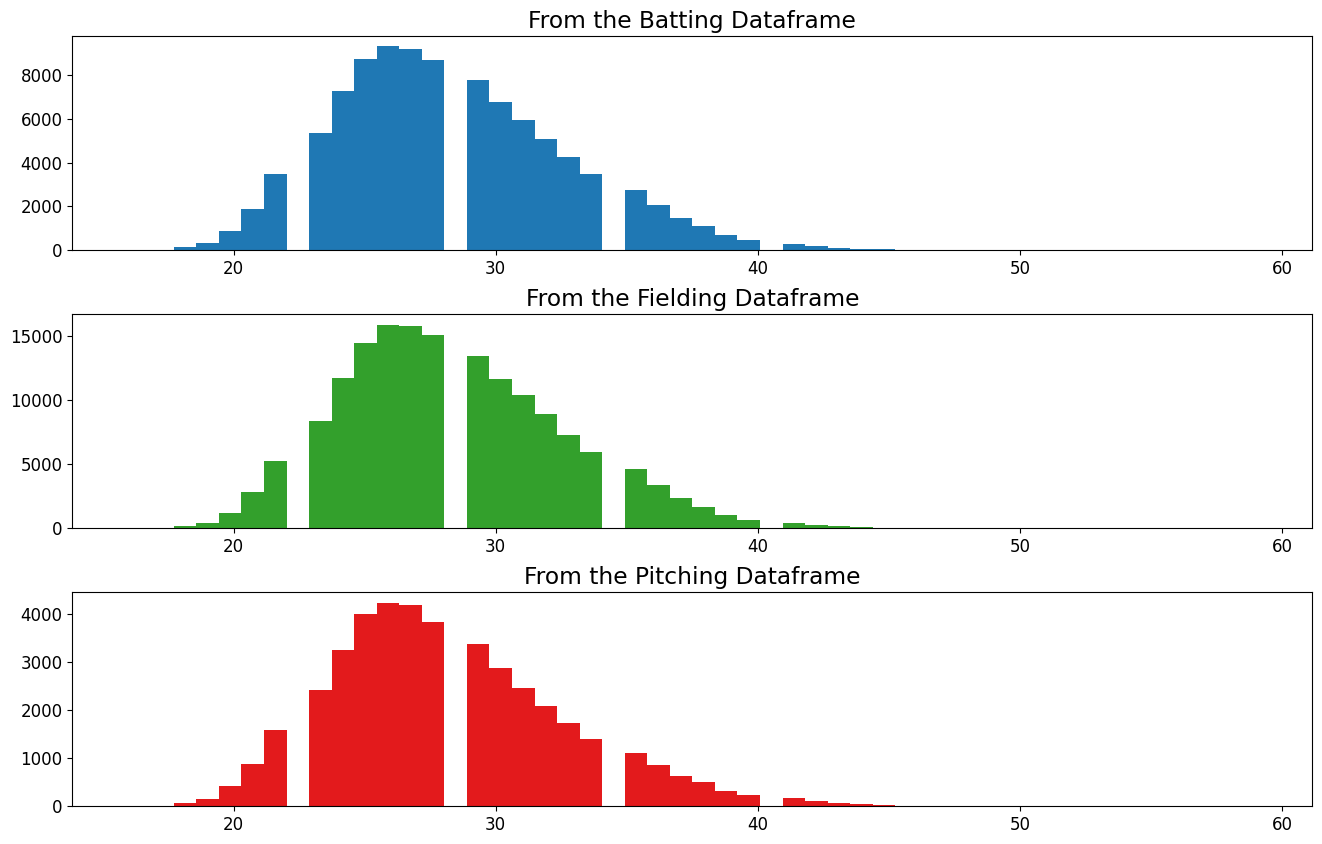

Batting df:  min: 16.0  max: 59.0
Fielding df: min: 16.0  max: 59.0
Pitching df: min: 16.0  max: 59.0


In [12]:
fig, ax = plt.subplots(3, 1)
ax[0].hist(batting['age'], bins = 50)
ax[0].set_title('From the Batting Dataframe')

ax[1].hist(fielding['age'], bins = 50, color = '#33a02c')
ax[1].set_title('From the Fielding Dataframe')

ax[2].hist(pitching['age'], bins = 50, color = '#e31a1c')
ax[2].set_title('From the Pitching Dataframe')

fig.subplots_adjust(hspace = 0.3)
plt.show()

print('Batting df:  min:', batting['age'].min(), ' max:', batting['age'].max())
print('Fielding df: min:', fielding['age'].min(), ' max:', fielding['age'].max())
print('Pitching df: min:', pitching['age'].min(), ' max:', pitching['age'].max())

These ages are not improbable, a 16 year old can play baseball quite well and if they are good enough they might just be drafted into the MLB. And though 59 is quite old for a professional baseball player, there are plenty of 60 year olds who are very physically active. Therefore, I will assume that all ages are now correctly assigned.

In [13]:
batting

,player_id,year,stint,team_id,league_id,g,ab,r,h,double,triple,hr,rbi,sb,cs,bb,so,hbp,sh,sf,adj_salary,weight,height,bmi,bats,throws,birth_year,age
0,addybo01,1876,1,CHN,NL,32,142.0,36.0,40.0,4.0,1.0,0.0,16.0,NaN,NaN,5.0,0.0,NaN,NaN,NaN,NaN,73.0,1.73,24.4,L,L,1842.0,34.0
1,allisar01,1876,1,LS1,NL,31,130.0,9.0,27.0,2.0,1.0,0.0,10.0,NaN,NaN,2.0,6.0,NaN,NaN,NaN,NaN,68.0,1.73,22.7,NaN,NaN,1849.0,27.0
2,allisdo01,1876,1,HAR,NL,44,163.0,19.0,43.0,4.0,0.0,0.0,15.0,NaN,NaN,3.0,9.0,NaN,NaN,NaN,NaN,73.0,1.78,23.0,R,R,1846.0,30.0
3,andrufr01,1876,1,CHN,NL,8,36.0,6.0,11.0,3.0,0.0,0.0,2.0,NaN,NaN,0.0,5.0,NaN,NaN,NaN,NaN,84.0,1.88,23.8,R,R,1850.0,26.0
4,ansonca01,1876,1,CHN,NL,66,309.0,63.0,110.0,9.0,7.0,2.0,59.0,NaN,NaN,12.0,8.0,NaN,NaN,NaN,NaN,103.0,1.83,30.8,R,R,1852.0,24.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97751,zitoba01,2015,1,OAK,AL,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,93.0,1.88,26.3,L,L,1978.0,37.0
97752,zobribe01,2015,1,OAK,AL,67,235.0,39.0,63.0,20.0,2.0,6.0,33.0,1.0,1.0,33.0,26.0,0.0,0.0,3.0,7500000.0,95.0,1.90,26.3,B,R,1981.0,34.0
97753,zobribe01,2015,2,KCA,AL,59,232.0,37.0,66.0,16.0,1.0,7.0,23.0,2.0,3.0,29.0,30.0,1.0,0.0,2.0,NaN,95.0,1.90,26.3,B,R,1981.0,34.0
97754,zuninmi01,2015,1,SEA,AL,112,350.0,28.0,61.0,11.0,0.0,11.0,28.0,0.0,1.0,21.0,132.0,5.0,8.0,2.0,523500.0,100.0,1.88,28.3,R,R,1991.0,24.0


In [14]:
fielding

,player_id,year,stint,team_id,league_id,pos,g,po,a,e,dp,adj_salary,weight,height,bmi,bats,throws,birth_year,age
0,addybo01,1876,1,CHN,NL,OF,32,46.0,6.0,13.0,0.0,NaN,73.0,1.73,24.4,L,L,1842.0,34.0
1,allisar01,1876,1,LS1,NL,1B,8,90.0,1.0,4.0,2.0,NaN,68.0,1.73,22.7,NaN,NaN,1849.0,27.0
2,allisar01,1876,1,LS1,NL,OF,23,34.0,11.0,12.0,1.0,NaN,68.0,1.73,22.7,NaN,NaN,1849.0,27.0
3,allisdo01,1876,1,HAR,NL,C,40,201.0,43.0,33.0,2.0,NaN,73.0,1.78,23.0,R,R,1846.0,30.0
4,allisdo01,1876,1,HAR,NL,OF,6,5.0,0.0,1.0,0.0,NaN,73.0,1.78,23.0,R,R,1846.0,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163711,younger03,2015,1,ATL,NL,OF,22,45.0,0.0,0.0,0.0,1000000.0,88.0,1.78,27.8,B,R,1985.0,30.0
163712,younger03,2015,2,NYN,NL,OF,7,5.0,0.0,0.0,0.0,NaN,88.0,1.78,27.8,B,R,1985.0,30.0
163713,zimmery01,2015,1,WAS,NL,OF,1,0.0,0.0,0.0,0.0,14000000.0,100.0,1.90,27.7,R,R,1984.0,31.0
163714,zobribe01,2015,1,OAK,AL,OF,29,39.0,0.0,3.0,0.0,7500000.0,95.0,1.90,26.3,B,R,1981.0,34.0


In [15]:
pitching

,player_id,year,stint,team_id,league_id,w,l,g,sho,sv,ipouts,h,er,hr,bb,so,era,hbp,bk,bfp,adj_salary,weight,height,bmi,bats,throws,birth_year,age
0,barnero01,1876,1,CHN,NL,0,0,1,0,0,4.0,7,3,0,0,0,20.25,NaN,0,13.0,NaN,66.0,1.73,22.1,R,R,1850.0,26.0
1,blongjo01,1876,1,SL3,NL,0,0,1,0,0,12.0,2,0,0,1,0,0.00,NaN,0,14.0,NaN,NaN,NaN,NaN,R,R,1853.0,23.0
2,bondto01,1876,1,HAR,NL,31,13,45,6,0,1224.0,355,76,2,13,88,1.68,NaN,0,1623.0,NaN,73.0,1.70,25.3,R,R,1856.0,20.0
3,bootham01,1876,1,CN1,NL,0,1,3,0,0,29.0,22,10,0,0,0,9.31,NaN,0,51.0,NaN,72.0,1.75,23.5,R,R,1848.0,28.0
4,boothed01,1876,1,NY3,NL,0,0,1,0,0,15.0,16,6,0,0,0,10.80,NaN,0,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43020,youngch03,2015,1,KCA,AL,11,6,34,0,0,370.0,91,42,16,43,83,3.06,0.0,0,500.0,675000.0,116.0,2.08,26.8,R,R,1979.0,36.0
43021,zieglbr01,2015,1,ARI,NL,0,3,66,0,30,204.0,48,14,3,17,36,1.85,1.0,0,263.0,5000000.0,100.0,1.93,26.8,R,R,1979.0,36.0
43022,zimmejo02,2015,1,WAS,NL,13,10,33,0,0,605.0,204,82,24,39,164,3.66,8.0,1,831.0,16500000.0,102.0,1.88,28.9,R,R,1986.0,29.0
43023,zitoba01,2015,1,OAK,AL,0,0,3,0,0,21.0,12,8,4,6,2,10.29,0.0,0,37.0,NaN,93.0,1.88,26.3,L,L,1978.0,37.0


In [16]:
team

,year,league_id,team_id,franchise_id,div_id,rank,g,w,l,div_win,wc_win,lg_win,ws_win,r,ab,h,double,triple,hr,bb,so,sb,cs,hbp,sf,era,sho,sv,ipouts,e
50,1876,NL,BSN,ATL,NaN,4,70,39,31,NaN,NaN,N,NaN,471,2722,723,96,24,9,58,98.0,NaN,NaN,NaN,NaN,2.51,3,7,1896,422
51,1876,NL,CHN,CHC,NaN,1,66,52,14,NaN,NaN,Y,NaN,624,2748,926,131,32,8,70,45.0,NaN,NaN,NaN,NaN,1.76,9,4,1776,282
52,1876,NL,CN1,CNR,NaN,8,65,9,56,NaN,NaN,N,NaN,238,2372,555,51,12,4,41,136.0,NaN,NaN,NaN,NaN,3.62,0,0,1773,469
53,1876,NL,HAR,HAR,NaN,2,69,47,21,NaN,NaN,N,NaN,429,2664,711,96,22,2,39,78.0,NaN,NaN,NaN,NaN,1.67,11,0,1872,337
54,1876,NL,LS1,LGR,NaN,5,69,30,36,NaN,NaN,N,NaN,280,2570,641,68,14,6,24,98.0,NaN,NaN,NaN,NaN,1.69,5,0,1929,396
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2800,2015,NL,LAN,LAD,W,1,162,92,70,Y,N,N,N,667,5385,1346,263,26,187,563,1258.0,59.0,34.0,60.0,30.0,3.44,21,47,4337,75
2801,2015,NL,SFN,SFG,W,2,162,84,78,N,N,N,N,696,5565,1486,288,39,136,457,1159.0,93.0,36.0,49.0,37.0,3.72,18,41,4333,78
2802,2015,NL,ARI,ARI,W,3,162,79,83,N,N,N,N,720,5649,1494,289,48,154,490,1312.0,132.0,44.0,33.0,57.0,4.04,12,44,4400,86
2803,2015,NL,SDN,SDP,W,4,162,74,88,N,N,N,N,650,5457,1324,260,36,148,426,1327.0,82.0,29.0,40.0,42.0,4.09,6,41,4321,92


All information has been correctly added to the datasets. Because there is no salary information until 1985, there will of course be a lot of missing values for salary, but when assessing players based on their salary I will exclude the missing values and the corresponding players to get consistent results.

### Getting an Overview of the Data

In this part of the project I want to get a general overview of the data I am using. This will also give a more comprehensive view of how different features are connected at to what extent. In addition I can use the information I get to improve the modeling I am going to perform later in the project.

To begin with I will look at how the batting features relate to each other.

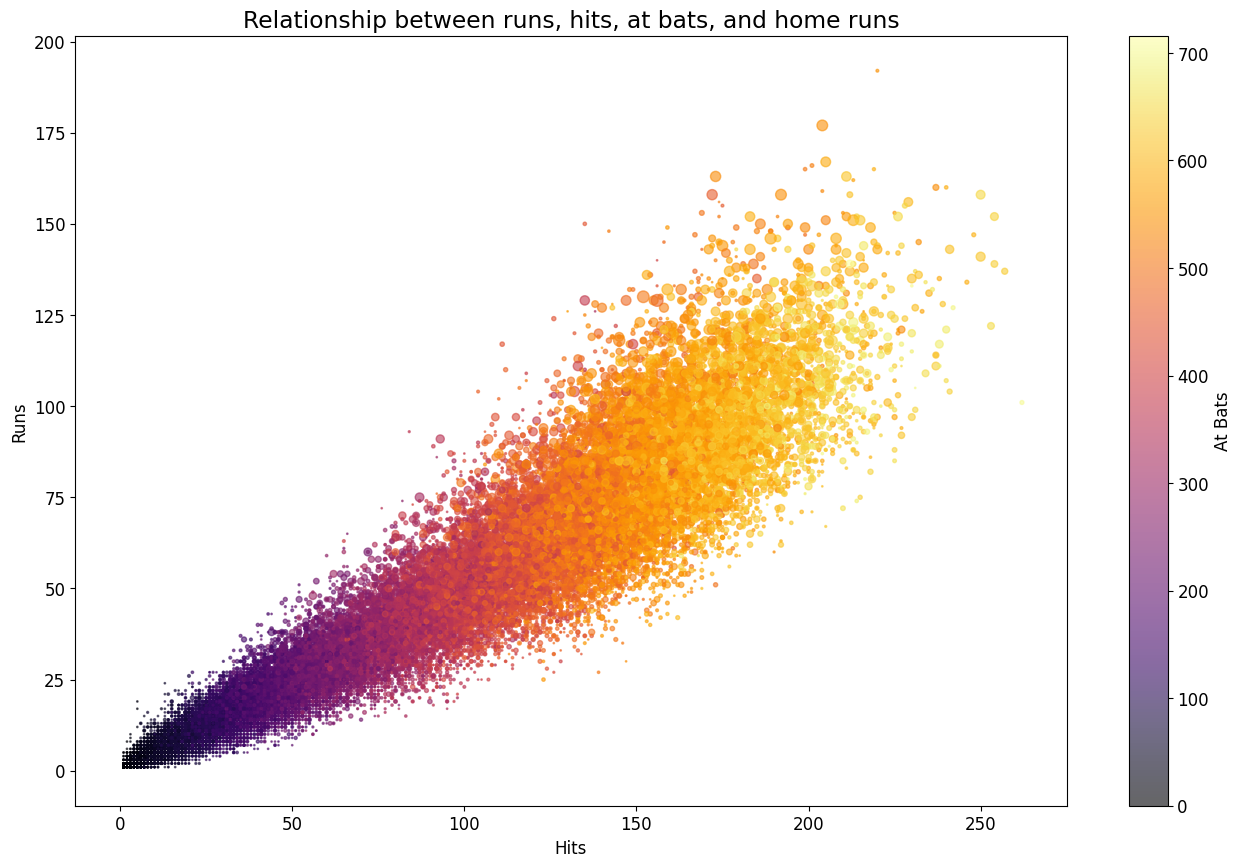

In [17]:
fig, ax = plt.subplots()
scatter = ax.scatter(batting['h'], batting['r'], alpha = .6, 
                     s = batting['hr'], c = batting['ab'], cmap = 'inferno')
col_bar = plt.colorbar(scatter, ax = ax)
ax.set_xlabel('Hits')
ax.set_ylabel('Runs')
col_bar.set_label('At Bats')
ax.set_title('Relationship between runs, hits, at bats, and home runs')
plt.show()

In the figure above, I have plotted how four central batting metrics relate to eachother. These are hits, runs, at bats, and home runs (displayed as the size of the datapoints). A hit happenes when a batter makes contact with a pitched ball and reaches the first base. A run is when a runner manages to make a complete round of the bases, he crosses all bases and reaches the home plate without being outed. An at bat is an official plate appearance on the batting plate, it is denoted by when the batter faces the picher an has the opportunity to reach a base or to be put out. A home run happens when a batter manages to bat the ball in a manner (usually over the outfield fence) that allows him to complete a complete round around the bases and consequently score a run. This visualization tells me that all four are positivly related, if a player manages more of one, they are more likely to do more of the others. 

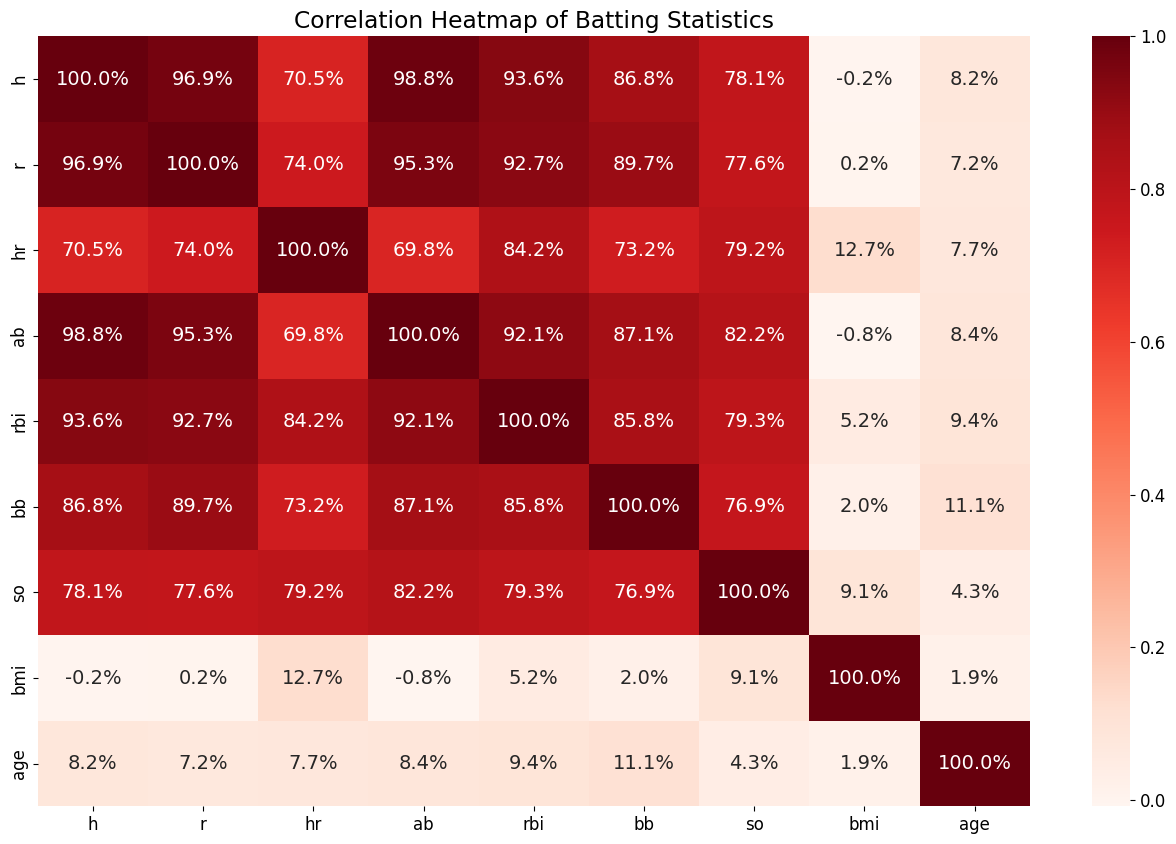

In [18]:
corr_matrix = batting[['h', 'r', 'hr', 'ab', 'rbi', 'bb', 'so', 'bmi', 'age']].corr()
sns.heatmap(corr_matrix, annot = True, cmap = 'Reds', fmt = '.1%')
plt.title('Correlation Heatmap of Batting Statistics')
plt.show()

This is a correlation matrix of the most important features in the batting dataset. The main thing I am pulling from this is that age and BMI unfortunately do not tell us much about the rest of the features. I also see that the rest of the features are very related to eachother. 

I will now look at the fielding data.

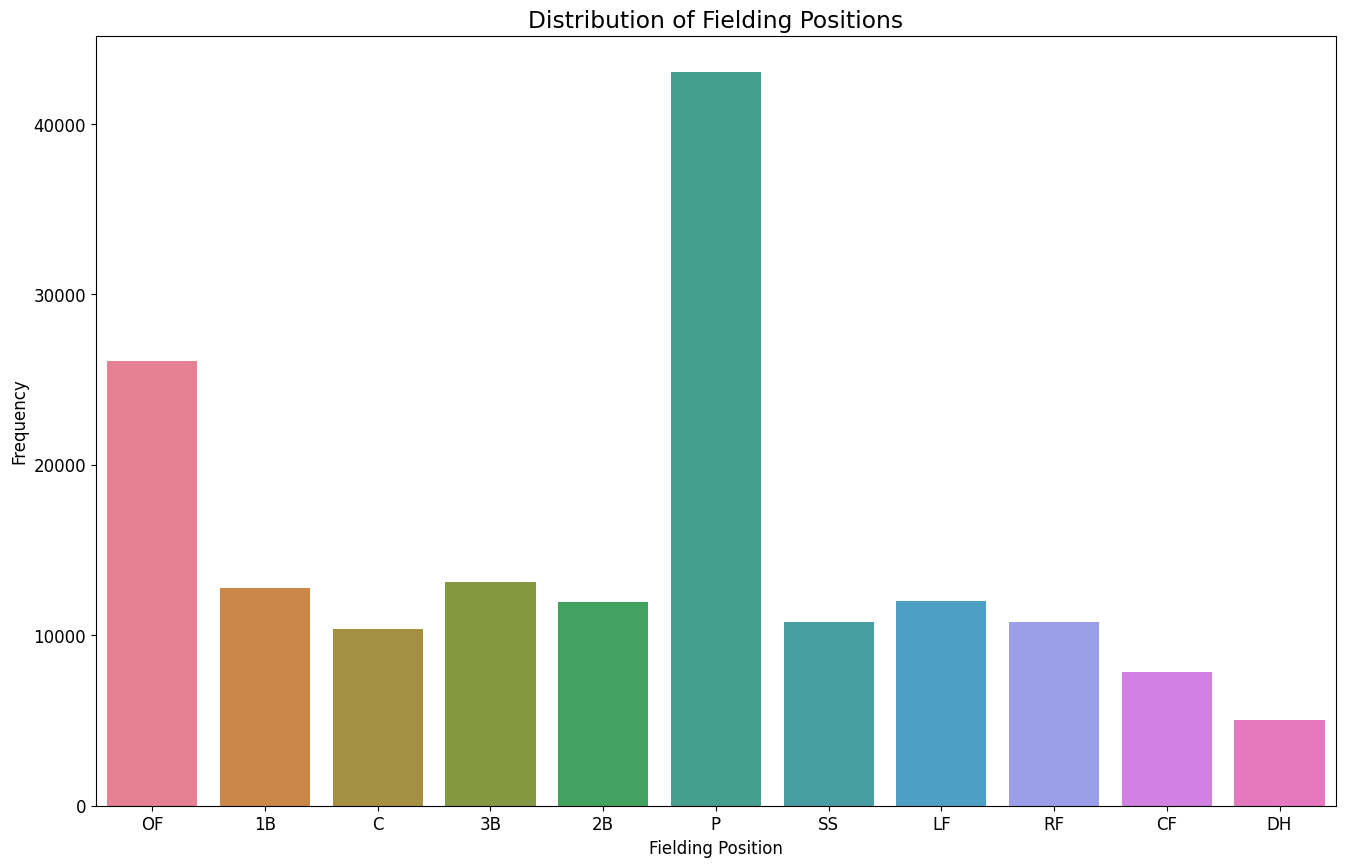

In [19]:
fig, ax = plt.subplots()
sns.countplot(data = fielding, x = 'pos', hue = 'pos')
ax.set_title('Distribution of Fielding Positions')
ax.set_xlabel('Fielding Position')
ax.set_ylabel('Frequency')
plt.show()

This figure shows the historical distribution of what positions a fielding player takes. These abbreviations represent the following: Infield: P (pitcher, the person pitching the ball), C (catcher, the person standing behind the batter catching pitched balls), 1B (first baseman, player standing close to the first base), 2B (second baseman, player standing near the second base), SS (shortstop, player positioned between second and third base, usually closer to the second base), 3B (thrid baseman, player standing close to the third base). Outfield: OF (outfielder, a colloquial term for a player standing in the outfield, used in the dataset for the earlier years), LF (leftfielder, player in the left section of the outfield), CF (centerfielder, player in the center section of the outfield), RF (rightfielder, player in the right section of the outfield). DH (designated hitter, for players in this position there is no data, so I am omitting this). This graph tells me there are a lot of players that are pitchers in the data, I can also see that there are a lot of players in the data who were playing in the outfield (OF, LF, CF, RF). 

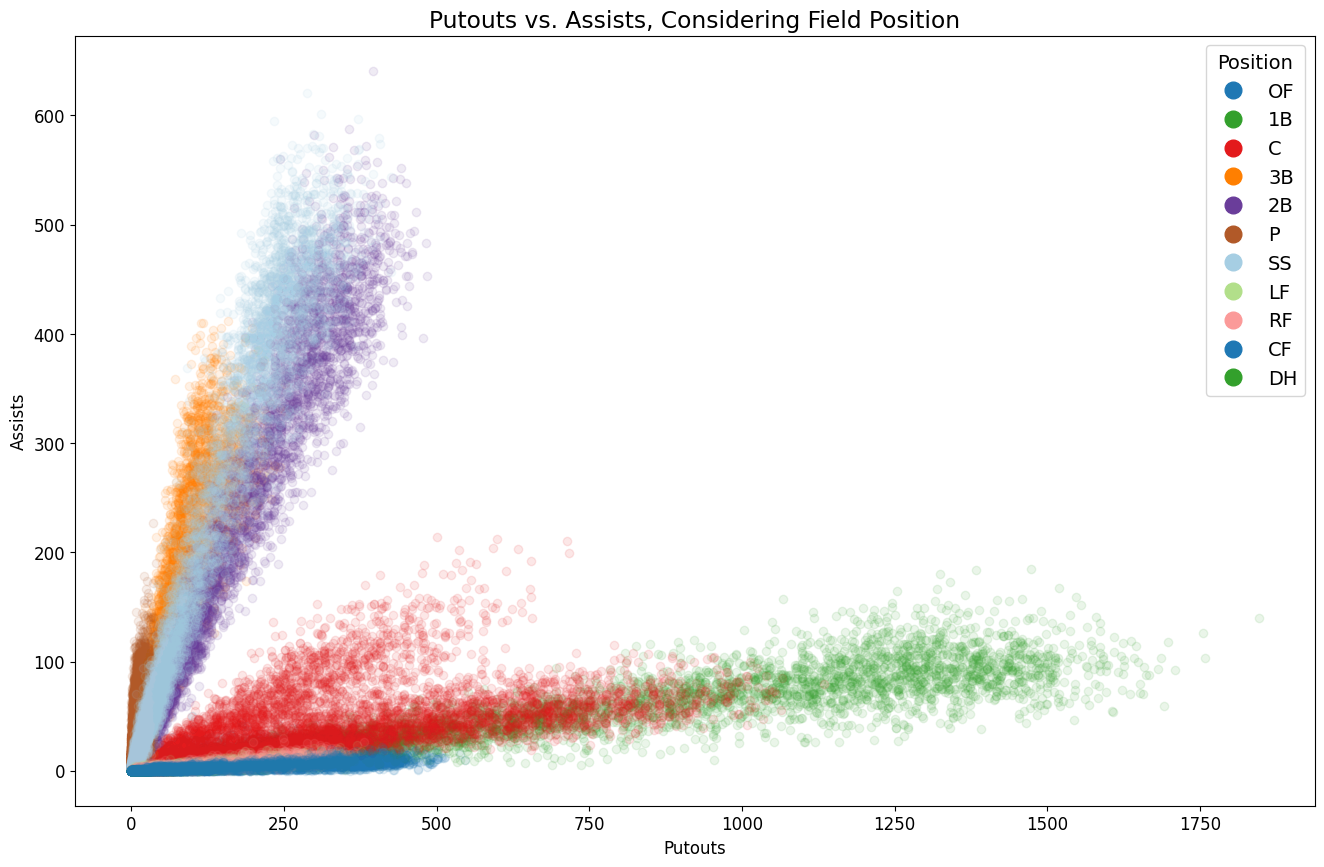

In [20]:
fig, ax = plt.subplots()
legends = []

# Looping thorugh the data for every position and plotting each position in 
# a different color. Also making the labels opaque.
for i, pos in enumerate(fielding['pos'].unique()):
    scat = (fielding['pos'] == pos)
    ax.scatter(fielding['po'][scat], fielding['a'][scat], alpha = .1)
    legends.append(plt.Line2D([], [], marker = 'o', color = f'C{i}', 
                                      markerfacecolor = f'C{i}', markersize = 12, 
                                      alpha = 1, label = pos, linewidth = 0))

ax.set_title('Putouts vs. Assists, Considering Field Position')
ax.set_xlabel('Putouts')
ax.set_ylabel('Assists')
plt.legend(handles = legends, title = 'Position')
plt.show()

This graph visualizes a how fielding player's number of putouts (when a defending player manages to out a runner) related to that players number of assists (when a fielding player is involved in a play that results in a runner being outed). The visualizationis not entirely clear because a lot of the points are placed on top of each other. However you can clearly see that the first baseman (green dots to three o'clock) has a lot of putouts and not a lot of assists, this makes sense because the first baseman is one of the most active positions and they are very often the one who outs a runner to begin with. You can also clearly see that the catcher has both a lot of putouts and assists, this comes from the catcher being part of a lot of strikeouts. The points toward one o'clock are the pitchers, second baseman, shortstop, and third baseman, these have a lot of assists and not a lot of putouts themselves, this comes from them very often throwing the ball to the first baseman for him to out the runner before he reaches first base. And what you cannot really see are the outfielders, but they are all located where the blue line at the bottom is, they have a few putouts but not a lot of assists. This comes from them being far out in the outfield and most of the balls are batted closer to the infield, making them more appropriate for the baseman to handle, they also have a good amount of putouts because a frequent occurence is them catching the ball before it hits the ground resulting in a putout.

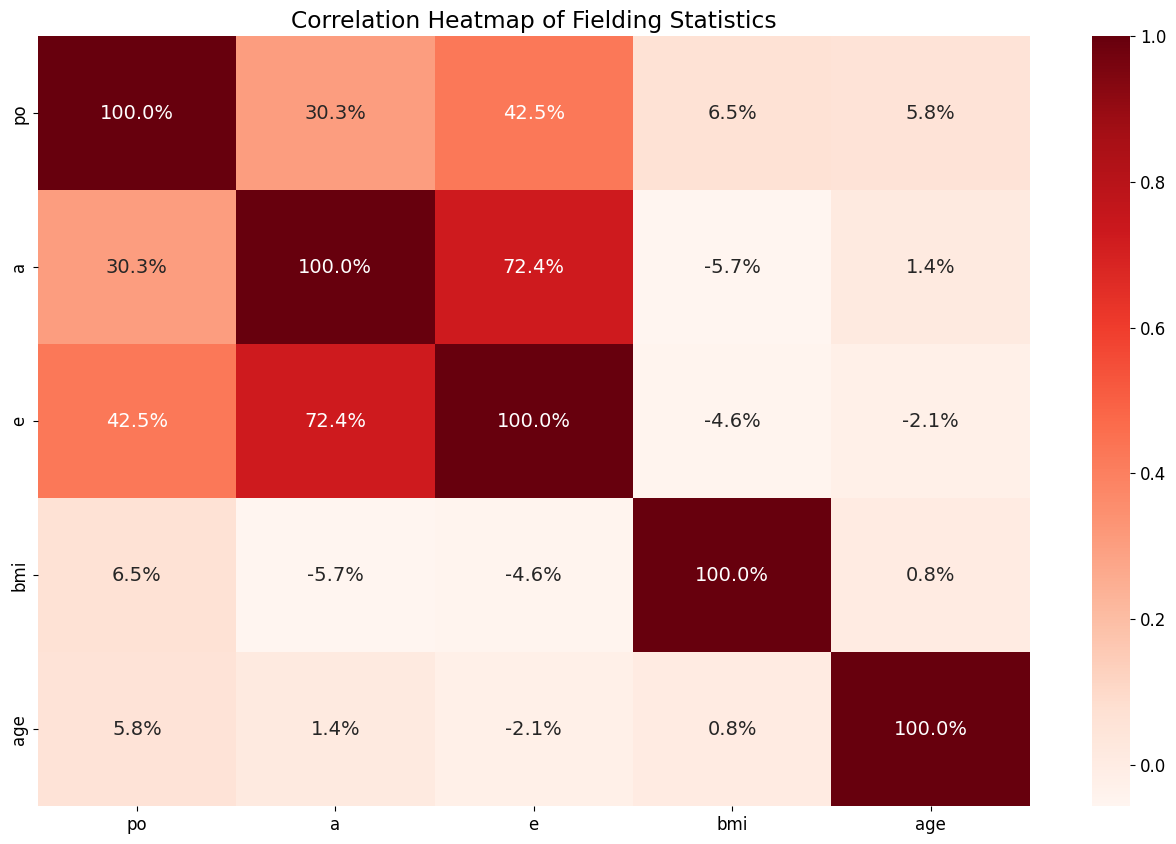

In [21]:
corr_matrix = fielding[['po', 'a', 'e', 'bmi', 'age']].corr()
sns.heatmap(corr_matrix, annot = True, cmap = 'Reds', fmt = '.1%')
plt.title('Correlation Heatmap of Fielding Statistics')
plt.show()

This is the correlation matrix for the fielding statistics, this, like the one for batting, shows that both age and BMI are not good predictors for any of the features in the data.

I will not look at the pitching data.

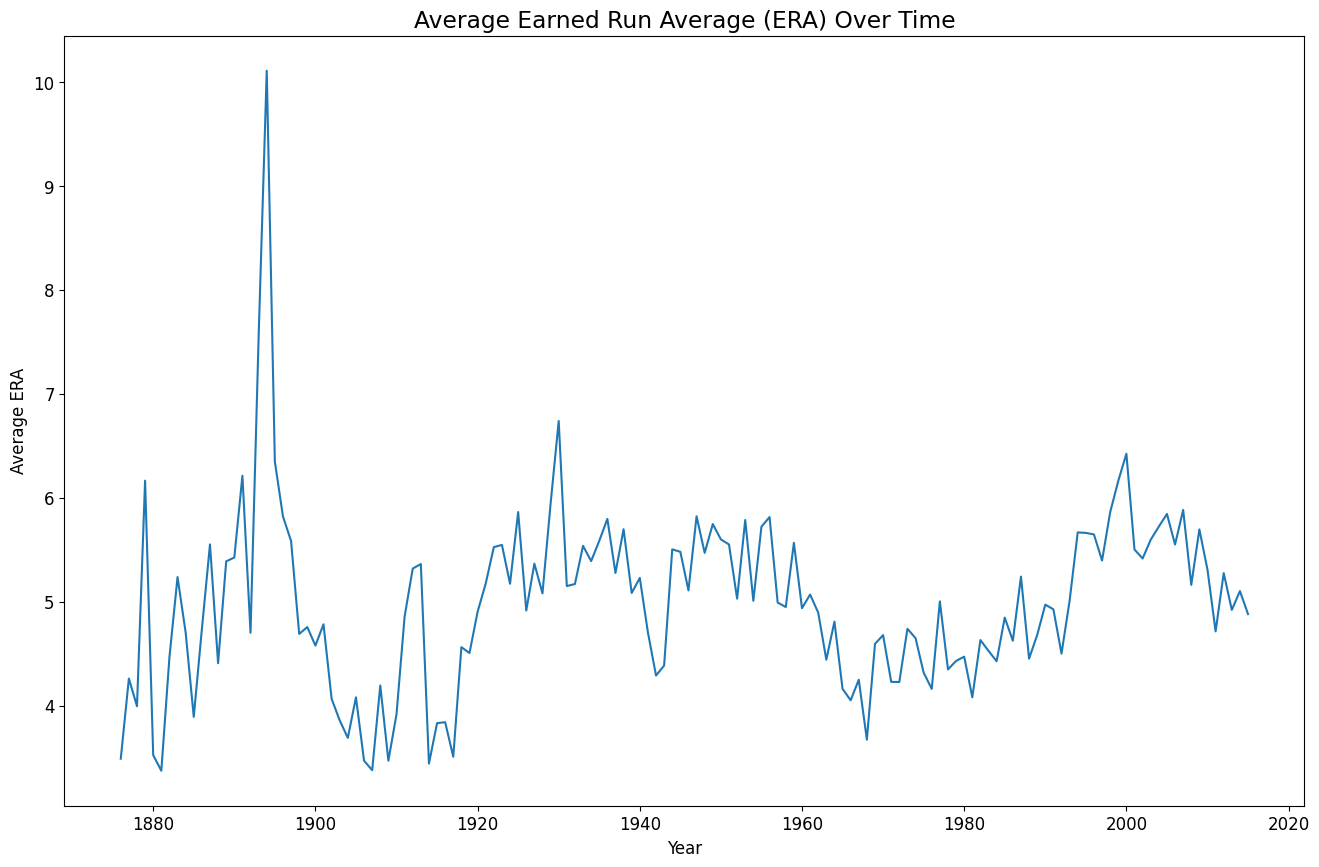

Mean:  5.072388960055897


In [22]:
fig, ax = plt.subplots()
ax.plot(pitching.groupby('year')['era'].mean())
ax.set_title('Average Earned Run Average (ERA) Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Average ERA')
plt.show()

print('Mean: ', pitching['era'].mean())

This graph shows what the historical changes in average ERA (earned run average) for all teams are. ERA is a metric that quantifies a pitchers effectiveness for preventing a runner from scoring a run. It is the average number of earned runs (runs scored without without aid from errors (mistake by fielder allowing runners to reach base) or passed balls) a pitcher allows per nine innings pitched. The graphs shows that the average for all pitchers is around 5 each year, there are of course some low- and high points, one in particular in the early 1900s, this may come from some missing data in the dataset or too few instances for that year, it is probably an anomaly.

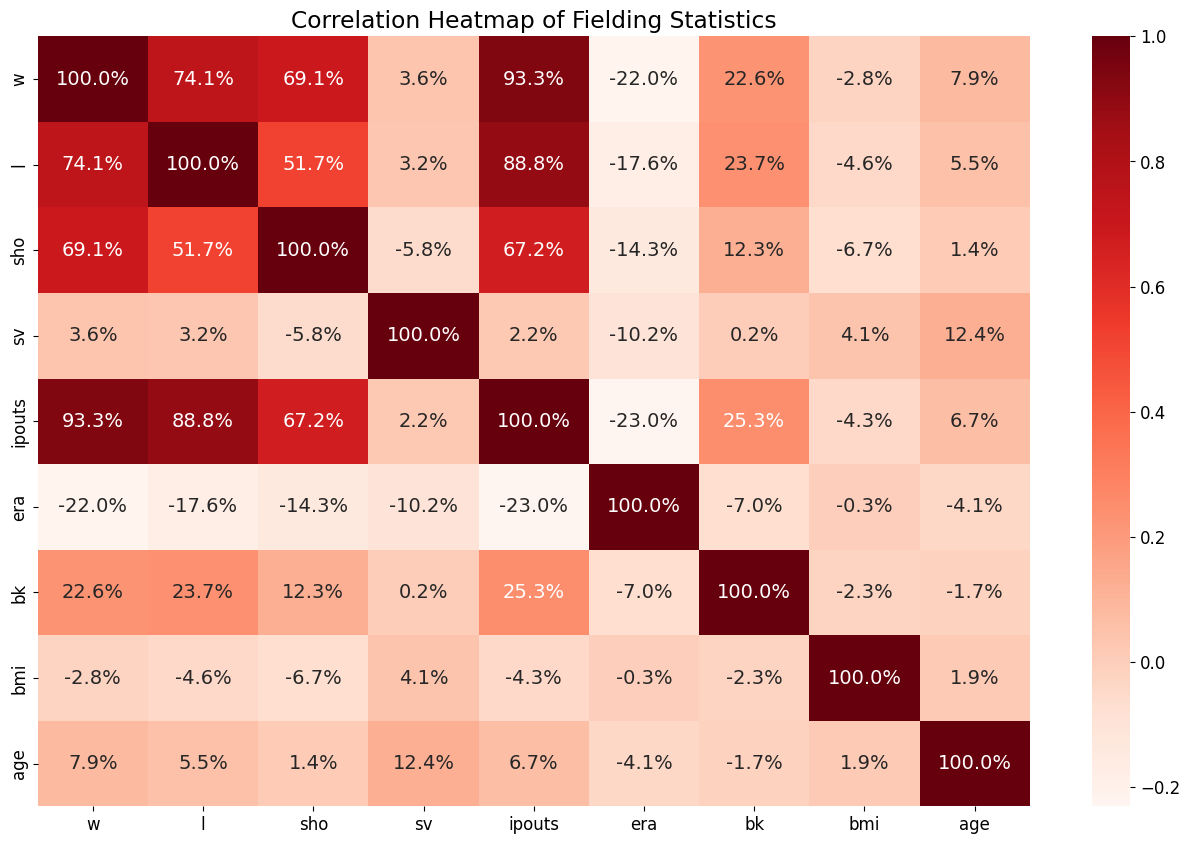

In [23]:
corr_matrix = pitching[['w', 'l', 'sho', 'sv', 'ipouts', 'era', 'bk', 'bmi', 'age']].corr()
sns.heatmap(corr_matrix, annot = True, cmap = 'Reds', fmt = '.1%')
plt.title('Correlation Heatmap of Fielding Statistics')
plt.show()

This is the correlation matrix for the pitchers, to begin with it shows, like the others, that age and BMI are not very relevant factors for the performance of a pitcher. It also shows that era, bk (balks, a rule violation), and sv (saves, when a pitcher comes into the game to perserve a lead or prevent tying or the other team from winning) are not very correlated with the other features. 

Next, I will look at the data for each team in each season. To begin with, I look at the winning percentage for each team, the winning percentage is calculated by:

$pct = \frac{Wins}{Wins + Losses}$

In [24]:
team['w_l_pct'] = team['w'] / (team['w'] + team['l'])

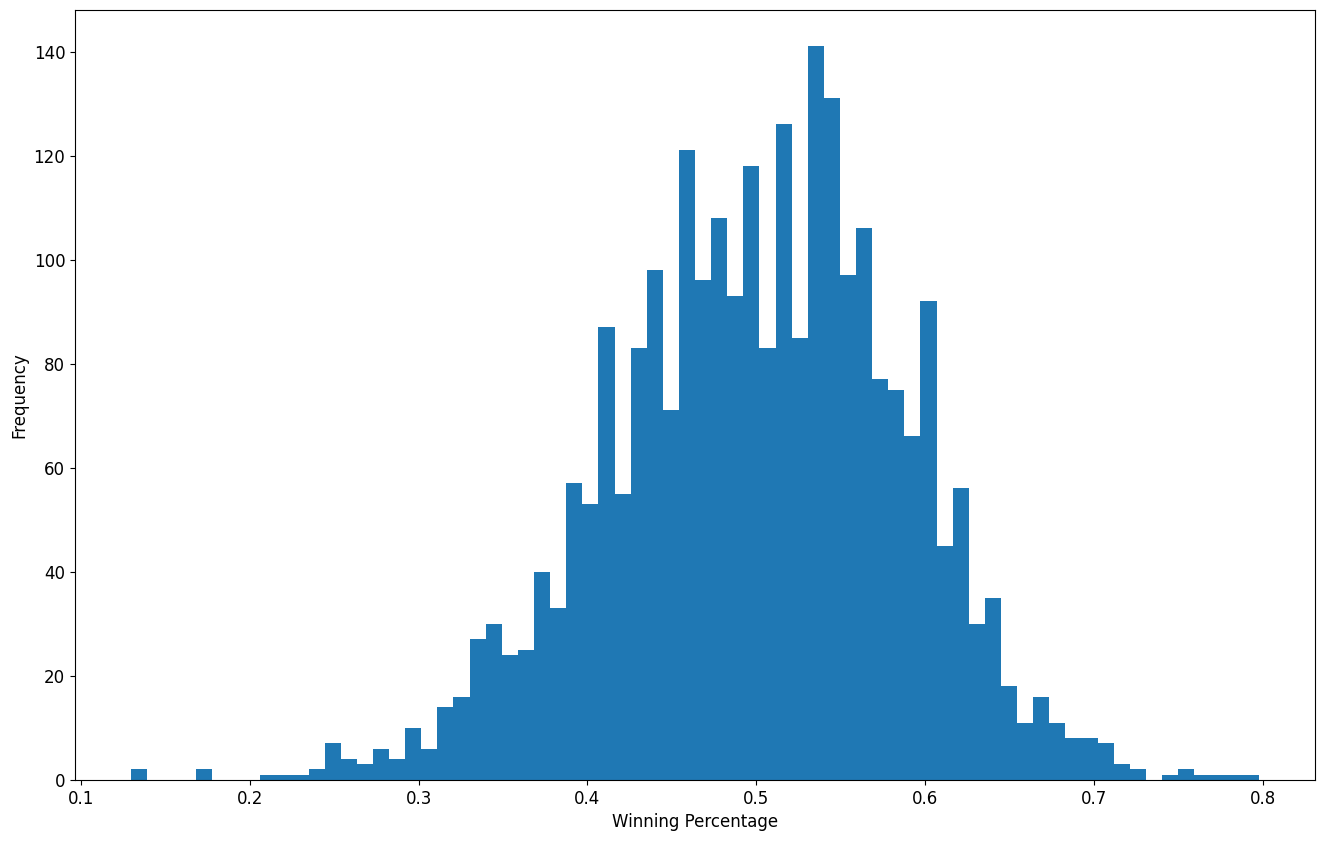

Mean: 0.49992237921823185  StD: 0.0875728170857077


In [25]:
fig, ax = plt.subplots()
ax.hist(team['w_l_pct'], bins = 70)
ax.set_xlabel('Winning Percentage')
ax.set_ylabel('Frequency')
plt.show()

print('Mean:', team['w_l_pct'].mean(), ' StD:', team['w_l_pct'].std())

The distribution of winning percentages tells me that a team has a winning percentage of around 50% most of the time. This distribution is quite normally distributed with a slight negative skew, meaning that there are more teams with a lower winning percentage than the mean (50%). 

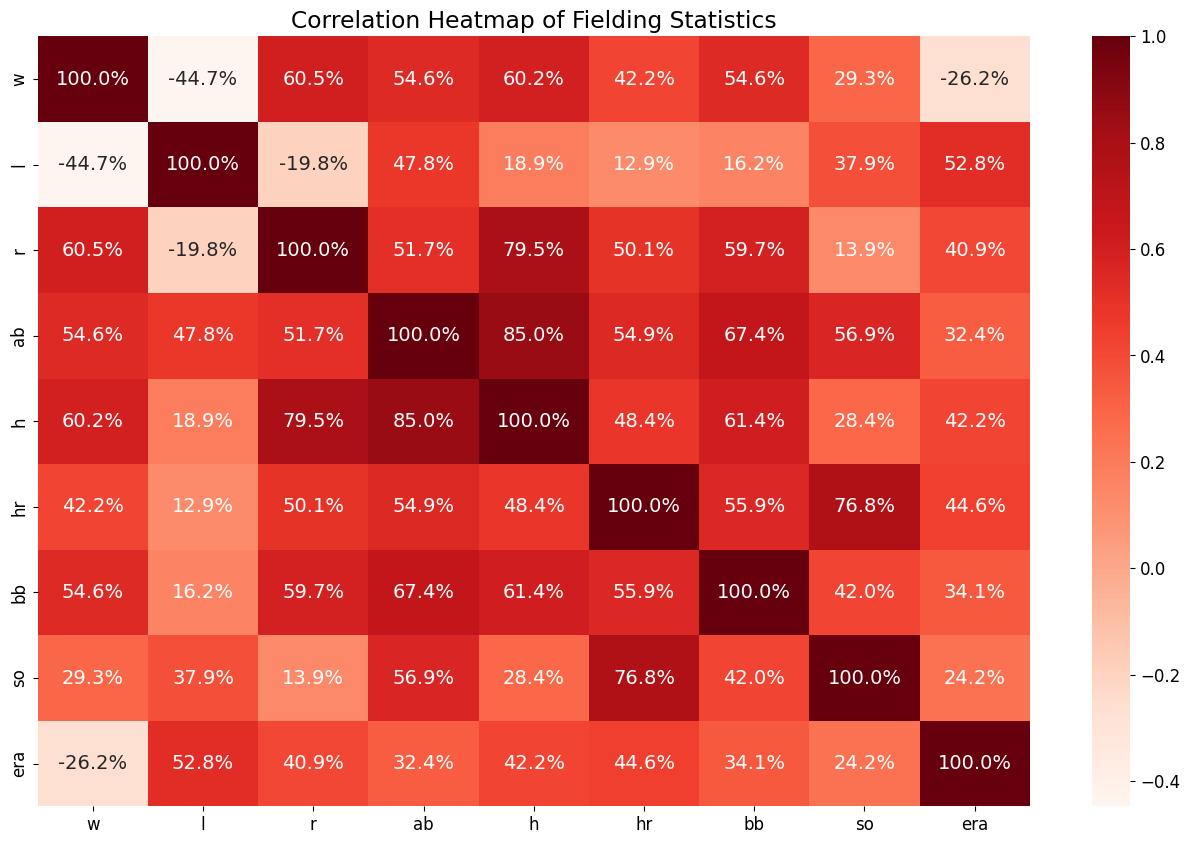

In [26]:
corr_matrix = team[['w', 'l', 'r', 'ab', 'h', 'hr', 'bb', 'so', 'era']].corr()
sns.heatmap(corr_matrix, annot = True, cmap = 'Reds', fmt = '.1%')
plt.title('Correlation Heatmap of Fielding Statistics')
plt.show()

This is the correlation matrix for the features in the team data. It shows that most of the features are only slightly correlated with eachother, there are some features that are more strongly correlated (hits with runs and at bats, and home runs with strikeouts), and some that are quite weakly correlated (losses with bb (walks, when a batter is awarded first base because the pitcher could not threw four balls outside the strikezone), home runs, hits, and runs. Also runs with strikeouts). Some are relatively strongly negatively correlated with each other (wins with era, and losses with wins).

### Modeling Simple Relationships With Linear Regression

In this part of the project I will model some simple relationships in the data to see whether some particular feature can be a good predictor for some central statistic in sabermetrics. I will be using linear regression with the ordinary least squares (OLS) method to model these relationships. OLS works by calculating the sum of the differences between the observed and predicted values squared, and minimizing this sum. For a simple linear regression, the formula we are trying to opimize looks like:

$Y = \alpha + \beta X$

Where $Y$ is the dependent variable, $X$ is the independent, $\alpha$ is the intercept term, and $\beta$ is the coefficient for the independent variable. For now I will be working with simple regression, but later I will work with multiple independent variables, here the formula look like:

$Y = \alpha + \beta_0X_0 + \beta_1X_1 + ... + \beta_nX_n$

For evaluating these models I will be looking at couple of indicators. $R^2$ is the coefficient of determination and it is an important indicator for how well the model fits the data, it tells us the propotion of variance in the dependent variable that is explained by the independent variable(s). An $R^2$ of 0 indicates a bad model, it tells us that the model is not explaining the variablility in the dependent variable, if it is 1 it says that the model perfectly explains the variability of the dependent variable. I will also be looking at the standard errors of the model parameters, this tells me how precise the estimated coefficient can be interpreted as.

I will also be looking at model uncertainty, both inferencial and predictive uncertainty. Inferential uncertainty is refering to the uncertainty around the estimates of the model parameters. The inferential uncertainty comes from the estimation of parameters that is based on sample data which may not represent the entire population we are trying to estimate for. Predictive uncertainty refers to the uncertainty around making predictions for new unseen data (data the model is not trained on). The predictive uncertainty is affected by factors like the inherent variability of the data, and the models ability to see the underlying patterns in the data. I will be visualizing the uncertainty by way of simulation. To do this, I will be using the **regSim** function that was devised in the labs as seen below.

In [27]:
def regSim(regMod): 
    #extract values from regression model
    nmk = regMod.df_resid #n-k
    sigma_hat = np.sqrt(regMod.mse_resid)
    bs_vcov = regMod.cov_params(scale = 1)
    bs = regMod.params
    
    #create simulated values
    sigma_sim = sigma_hat * np.sqrt(nmk / np.random.chisquare(nmk, 1))
    V_sim = np.array(bs_vcov) * sigma_sim ** 2
    bs_sim = np.random.multivariate_normal(bs, V_sim, 1)
    
    return bs_sim.flatten(), sigma_sim

In [28]:
def plotSimpleRegWithUncertainty(model, data, depVar, indepVar, depLabel, 
                                 indepLabel, nsims = 100, alphaInf = 1, alphaPre = .2):
    # Simulate the cofficients.
    beta_sims = []
    for s in range(nsims):
        beta_sim, sigma_sim = regSim(model)
        beta_sims.append(beta_sim)

    fig, ax = plt.subplots()
    ax.scatter(data[indepVar], data[depVar], alpha = .2)

    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    y_line = model.params.iloc[0] + model.params.iloc[1] * x

    # Plot the regression line.
    ax.plot(x, y_line, color = 'black', zorder = 10)

    # Plot the interential uncertainty.
    for i in range(nsims):
        y_line_sim = beta_sims[i][0] + beta_sims[i][1] * x
        ax.plot(x, y_line_sim, color = 'red', alpha = alphaInf)
    
    ax.set_xlabel(indepLabel)
    ax.set_ylabel(depLabel)
    ax.set_title(f'Relationship Between {depLabel} and {indepLabel}, Showing Inferential Uncertainty')

    fig, ax = plt.subplots()
    ax.scatter(data[indepVar], data[depVar], alpha = .2)

    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    y_line = model.params.iloc[0] + model.params.iloc[1] * x

    # Plot the regression line.
    ax.plot(x, y_line, color = 'black', zorder = 10)

    # Plot the predictive uncertainty.
    sigma_hat = np.sqrt(model.mse_resid)
    for i in range(nsims):
        y_line_sim = beta_sims[i][0] + beta_sims[i][1] * x + np.random.normal(0, sigma_hat)
        ax.plot(x, y_line_sim, color = 'red', alpha = alphaPre)
    
    ax.set_xlabel(indepLabel)
    ax.set_ylabel(depLabel)
    ax.set_title(f'Relationship Between {depLabel} and {indepLabel}, Showing Predictive Uncertainty')
    plt.show()

This function above has three functions which will help me streamline the visualization of the regression result along with the visualization of uncertainty. It calculates the inferential and predictive uncertainty and it shows the graphs of the regression line with the data.

##### Batting

To begin with I will be making two models trying to explain the relationship between some central statistics in sabermetrics and a particular feature from the batting dataset. To begin with I will see how well RBI (runs batted in, the amount of runs that have been scored by a team because a batter batted a ball so players already on base can run home) can explain OBP (on-base percentage, a measure for a players ability to reach base safely).  OBP is calculated by:

$OBP = \frac{h + bb + hbp}{ab + bb + hbp + sf}$

Where **h** is hits, **bb** is walks, **hbp** is hit by pitches (when a pitcher throws the ball at the batter and the batter is allowed to move to first base), **ab** is at bats, and **sf** is sacrifice flies (when a batter hits a ball that is caught by a defensive player before it hits the ground resulting in a putout, but while the ball is in the air a run is scored by a runner who was already on base). 

In [29]:
batting['OBP'] = (batting['h'] + batting['bb'] + batting['hbp']) / (batting['ab'] + batting['bb'] + batting['hbp'] + batting['sf'])

In [30]:
mod1 = smf.ols('OBP ~ rbi', data = batting).fit()
mod1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    OBP   R-squared:                       0.144
Model:                            OLS   Adj. R-squared:                  0.144
Method:                 Least Squares   F-statistic:                     8544.
Date:                Fri, 15 Dec 2023   Prob (F-statistic):               0.00
Time:                        03:54:30   Log-Likelihood:                 30231.
No. Observations:               50825   AIC:                        -6.046e+04
Df Residuals:                   50823   BIC:                        -6.044e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2207      0.001    301.841      0.000       0.219       0.222
rbi            0.0020   2.12e-05     92.433      0.000       0.002       0.002
==============================================================================
Omnibus:                    19299.964   Durbin-Watson:                   1.963
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           187314.096
Skew:                           1.554   Prob(JB):                         0.00
Kurtosis:                      11.877   Cond. No.                         42.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The first thing I notice in this regression is that the $R^2$ is very low indicating that the model does not attain a good fit. The standard errors are however very low. The intercept is .22 telling me that when a player does not bat any players in (RBI = 0) we can expect an OBP of .22. The coefficient for RBI is .002, which is low, but since I am estimating a percentage it tells me that when a player bats in one more player the OBP increases by .002 points. 

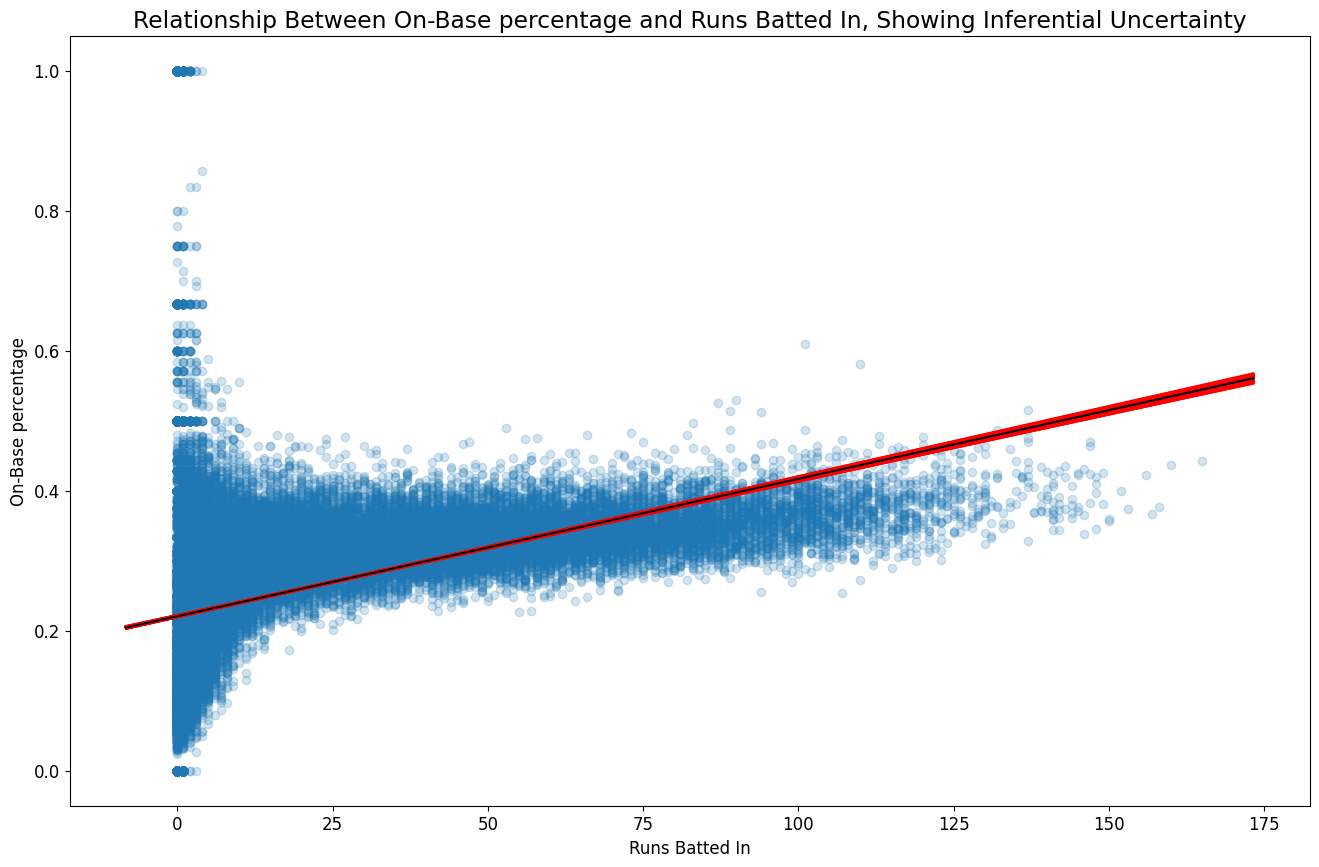

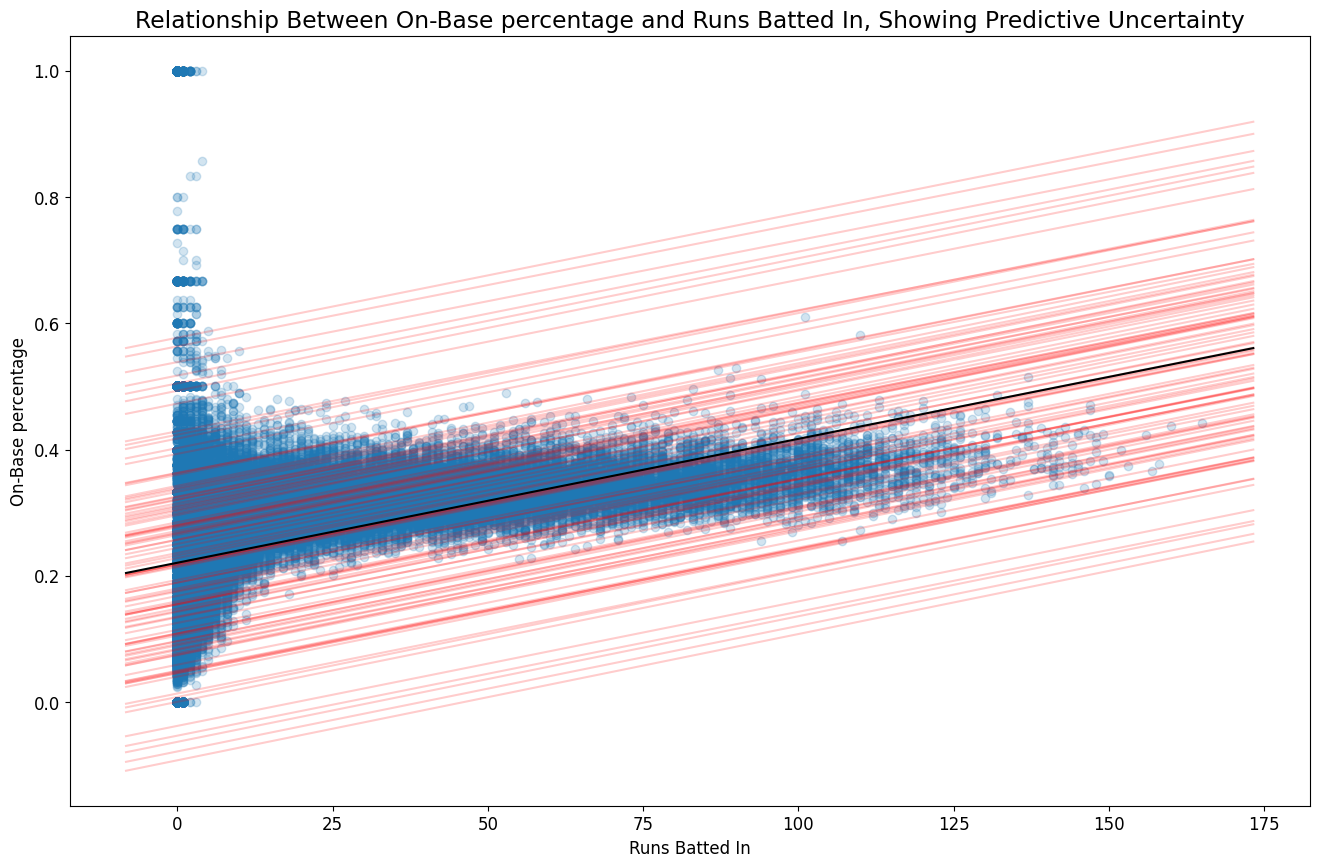

In [31]:
plotSimpleRegWithUncertainty(mod1, batting, 'OBP', 'rbi', 'On-Base percentage', 'Runs Batted In')

We can see from the data that there is some linear relationship between the data, but there is a lot of variablity in the lower levels of RBI, a lot of outliers, which I expect to be the source of the bad fit. The linear relationship is very horizontal, so in general the RBI does not tell us much about OBP, there is only a slight increase in OBP with a big increase in RBI. As you can see, the predictive uncertainty is also substantial.

Next, for batting, I will be looking at the possible relationship between strikeouts and batting average (a traditional measure for a batters success at the plate, how often a batter can hit the ball every time he is on the plate). Batting average is calculated by:

$AVG = \frac{h}{ab}$

Where **h** is hits and **ab** is at bats. 

In [32]:
batting['AVG'] = batting['h'] / batting['ab']

In [33]:
mod2 = smf.ols('AVG ~ so', data = batting).fit()
mod2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    AVG   R-squared:                       0.073
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     6042.
Date:                Fri, 15 Dec 2023   Prob (F-statistic):               0.00
Time:                        03:54:33   Log-Likelihood:                 54377.
No. Observations:               76924   AIC:                        -1.087e+05
Df Residuals:                   76922   BIC:                        -1.087e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1799      0.001    320.022      0.000       0.179       0.181
so             0.0011   1.47e-05     77.729      0.000       0.001       0.001
==============================================================================
Omnibus:                    35285.643   Durbin-Watson:                   1.923
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           482337.636
Skew:                           1.852   Prob(JB):                         0.00
Kurtosis:                      14.695   Cond. No.                         49.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

This model has an even worse $R^2$ than the last, the batting average is not explained well at all from the strikeouts. Here the intercept is .18 and the percentage increase is .001 for a one unit increase in strikeouts. 

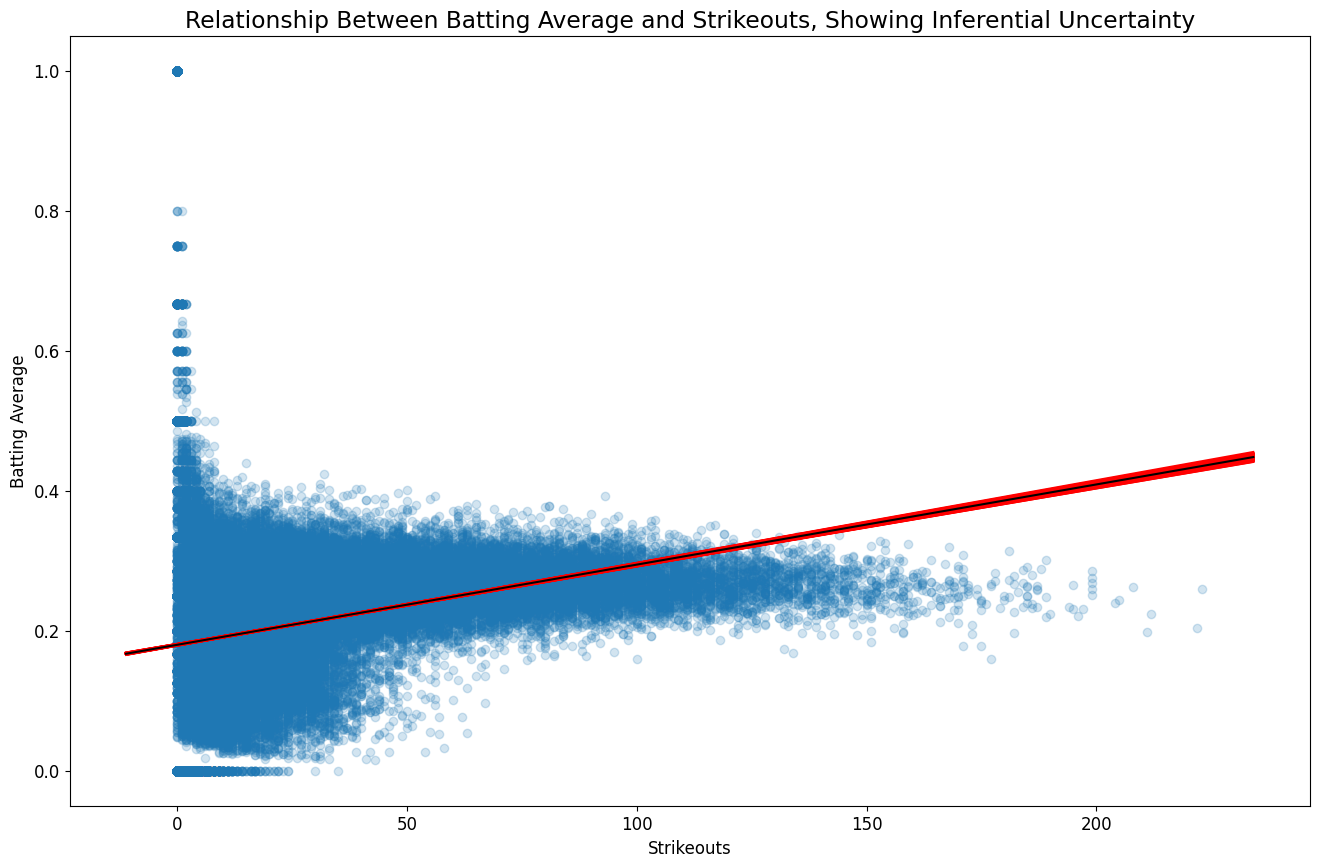

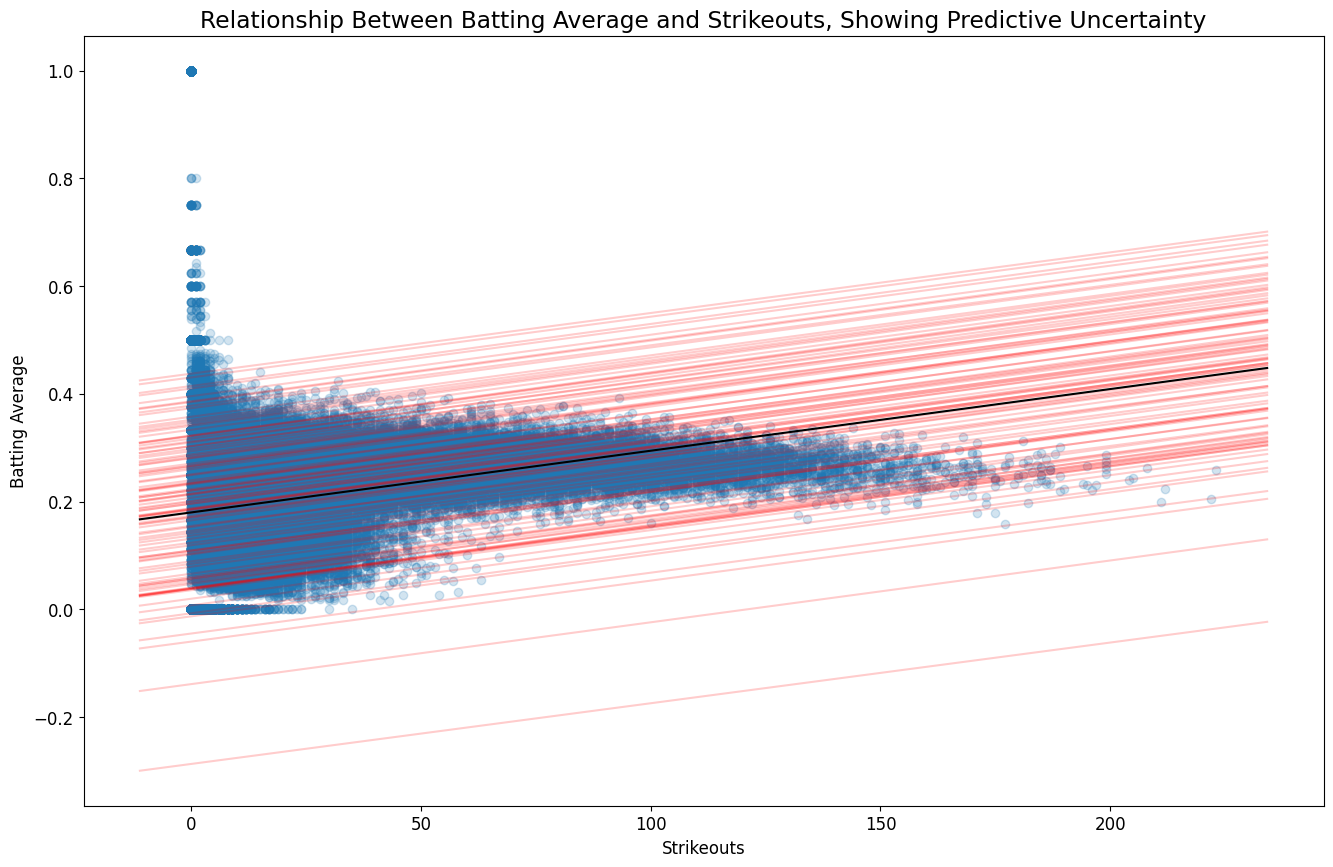

In [34]:
plotSimpleRegWithUncertainty(mod2, batting, 'AVG', 'so', 'Batting Average', 'Strikeouts')

As you can see there is a lot of uncertainty, which can be understood by the bad relationship between the variables.

##### Fielding

For the fielding data, I will be looking at the possible relationship between fielding percentage and errors committed. The fielding percentage tells us how often a fielder makes an appropriate play when he is tasked with handling a batted ball, it tells us how consistent he is when throwing or recieving a ball. In other words I want to see whether a player with more errors will have a worse fielding percentage. The fielding percentage is calculated by:

$FPCT = \frac{po + a}{po + a + e}$

Where **po** is putouts, **a** is assists, and **e** is errors. 

In [35]:
fielding['FPCT'] = (fielding['po'] + fielding['a']) / (fielding['po'] + fielding['a'] + fielding['e'])

In [36]:
mod3 = smf.ols('FPCT ~ e', data = fielding).fit()
mod3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   FPCT   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     1253.
Date:                Fri, 15 Dec 2023   Prob (F-statistic):          3.42e-273
Time:                        03:54:37   Log-Likelihood:             1.3139e+05
No. Observations:              139739   AIC:                        -2.628e+05
Df Residuals:                  139737   BIC:                        -2.628e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.9601      0.000   3402.534      0.000       0.960       0.961
e             -0.0013   3.65e-05    -35.394      0.000      -0.001      -0.001
==============================================================================
Omnibus:                   158167.686   Durbin-Watson:                   1.818
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         14553533.004
Skew:                          -5.986   Prob(JB):                         0.00
Kurtosis:                      51.541   Cond. No.                         8.67
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

As you can see the $R^2$ is very low here, indicating that errors do not explain fielding percentage very well. The model does however estimate that if a player commits one more error the fielding percentage will be decreased by .001 points with very low standard error. 

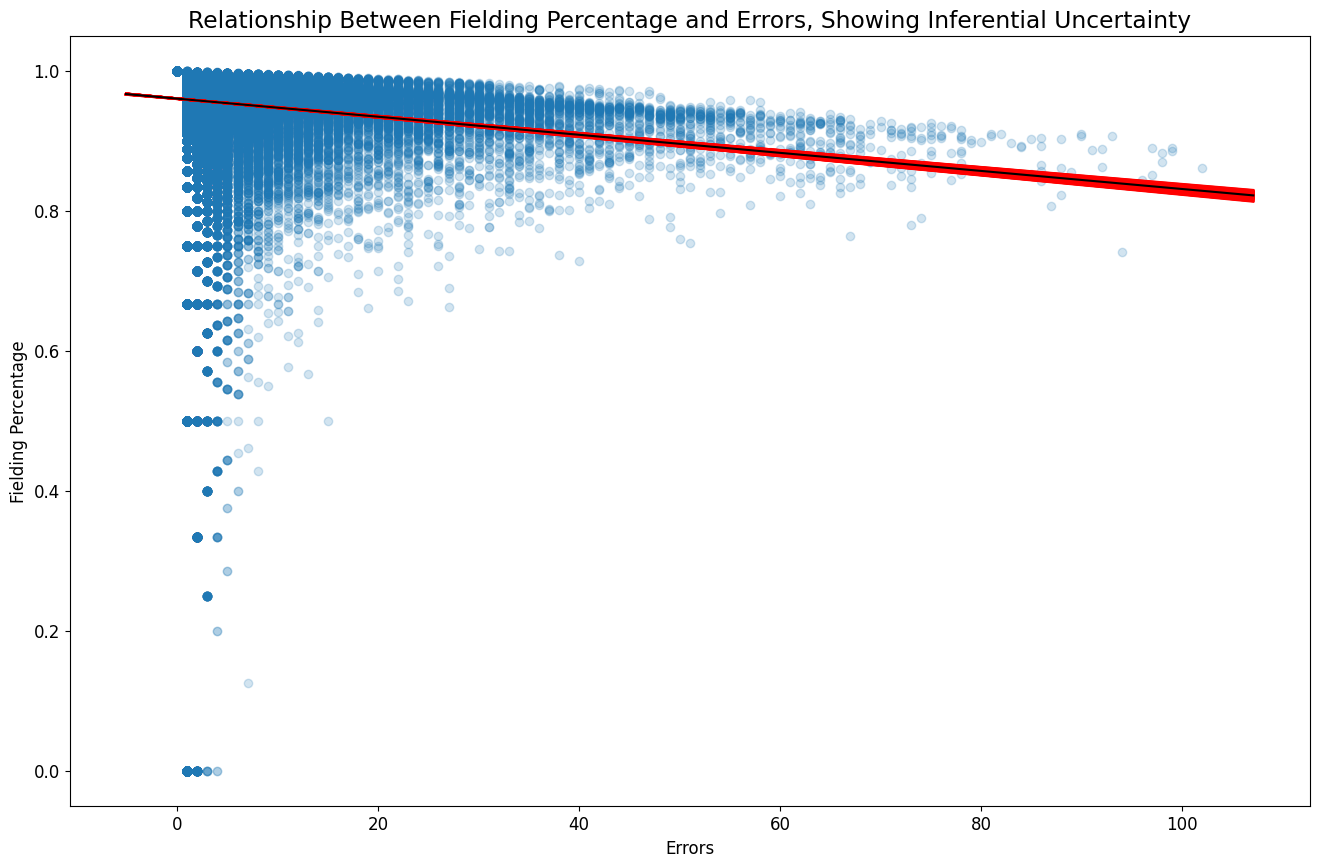

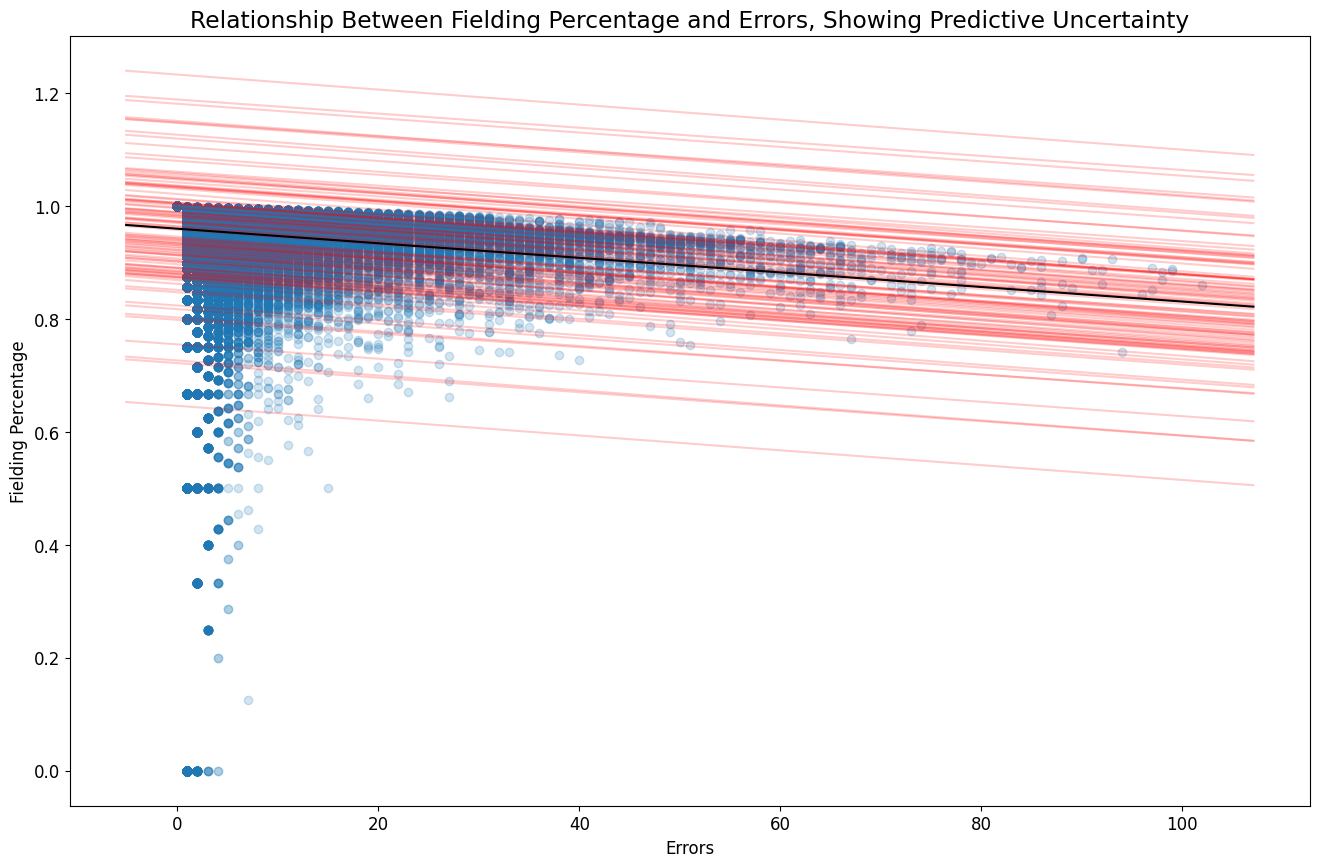

In [37]:
plotSimpleRegWithUncertainty(mod3, fielding, 'FPCT', 'e', 'Fielding Percentage', 'Errors')

The plot of the data shows that there is not necassarily an obvious decrease in fielding percentage, but by about 50 errors, the fielding percentage drops slightly. 

##### Pitching

For the pitching data I am going to be exploring the possible relationship between hits (the number of hits that is 'allowed' in by a pitcher where the batter hits the ball and reaches first base) and walk rate (the frequency that a picher walks hitters). I want to determine whether a pitcher with more hits allowed will walk fewer batters. The walk rate is calculated by:

$BBPCT = \frac{bb}{bfp}$

Where **bb** is walks and **bfp** is batters faced by pitcher (the number of batters a pitcher piches the ball to).

In [38]:
pitching['BBPCT'] = pitching['bb'] / pitching['bfp']

The calculation of walk rate results in some infinite values in the data so I will remove these.

In [39]:
pitching['BBPCT'] = pitching['BBPCT'].replace([np.inf, -np.inf], np.nan)

In [40]:
pitching_na = pitching.dropna(subset = ['BBPCT'])

In [41]:
mod4 = smf.ols('BBPCT ~ h', data = pitching_na).fit()
mod4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  BBPCT   R-squared:                       0.086
Model:                            OLS   Adj. R-squared:                  0.086
Method:                 Least Squares   F-statistic:                     3928.
Date:                Fri, 15 Dec 2023   Prob (F-statistic):               0.00
Time:                        03:54:41   Log-Likelihood:                 61729.
No. Observations:               41617   AIC:                        -1.235e+05
Df Residuals:                   41615   BIC:                        -1.234e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1162      0.000    299.502      0.000       0.115       0.117
h             -0.0002   3.39e-06    -62.674      0.000      -0.000      -0.000
==============================================================================
Omnibus:                    37635.131   Durbin-Watson:                   1.933
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          3717878.731
Skew:                           3.980   Prob(JB):                         0.00
Kurtosis:                      48.615   Cond. No.                         165.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

This model also has a rather low $R^2$ indicating a bad fit. The coefficient for hits is also miniscule, though negative. This tells me that this relationship is not really existant. 

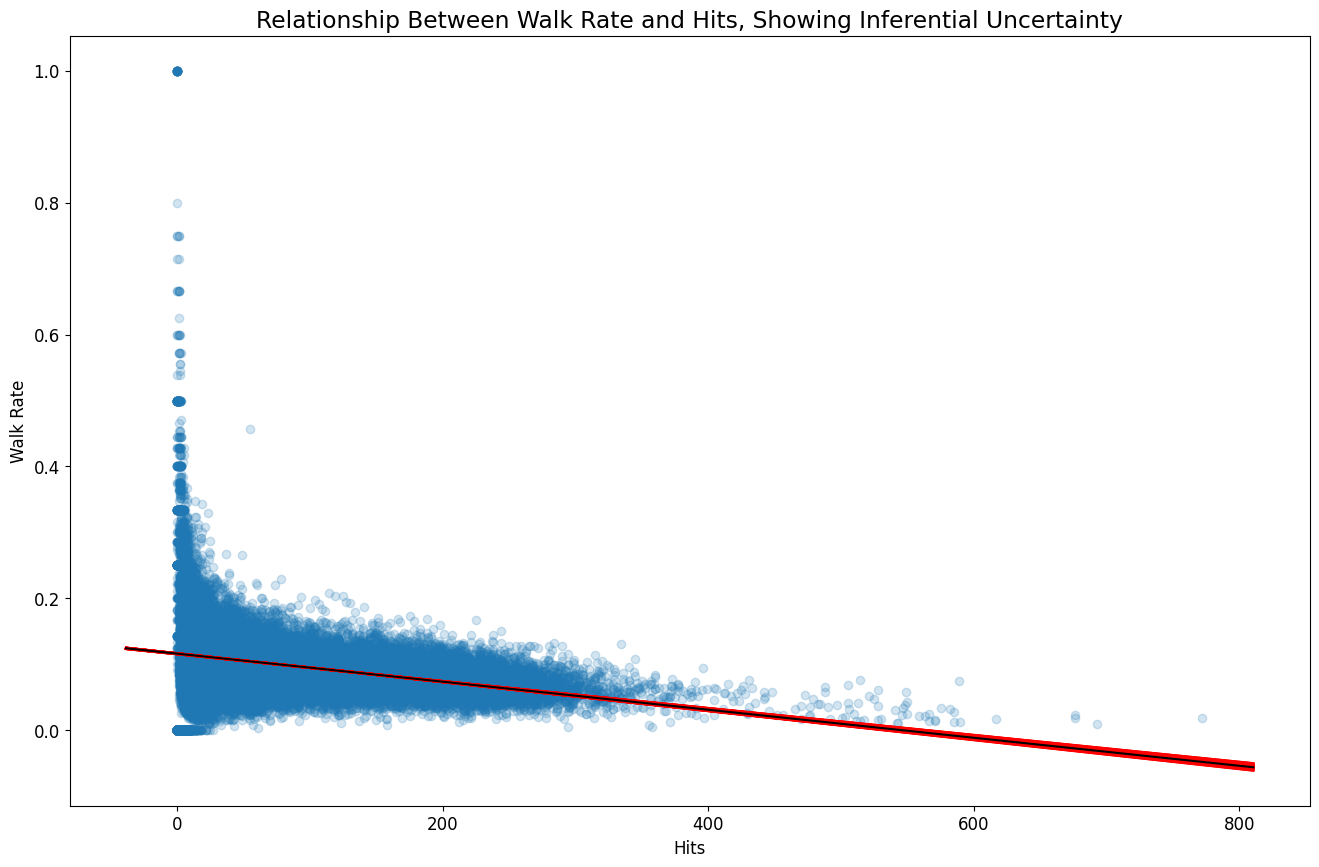

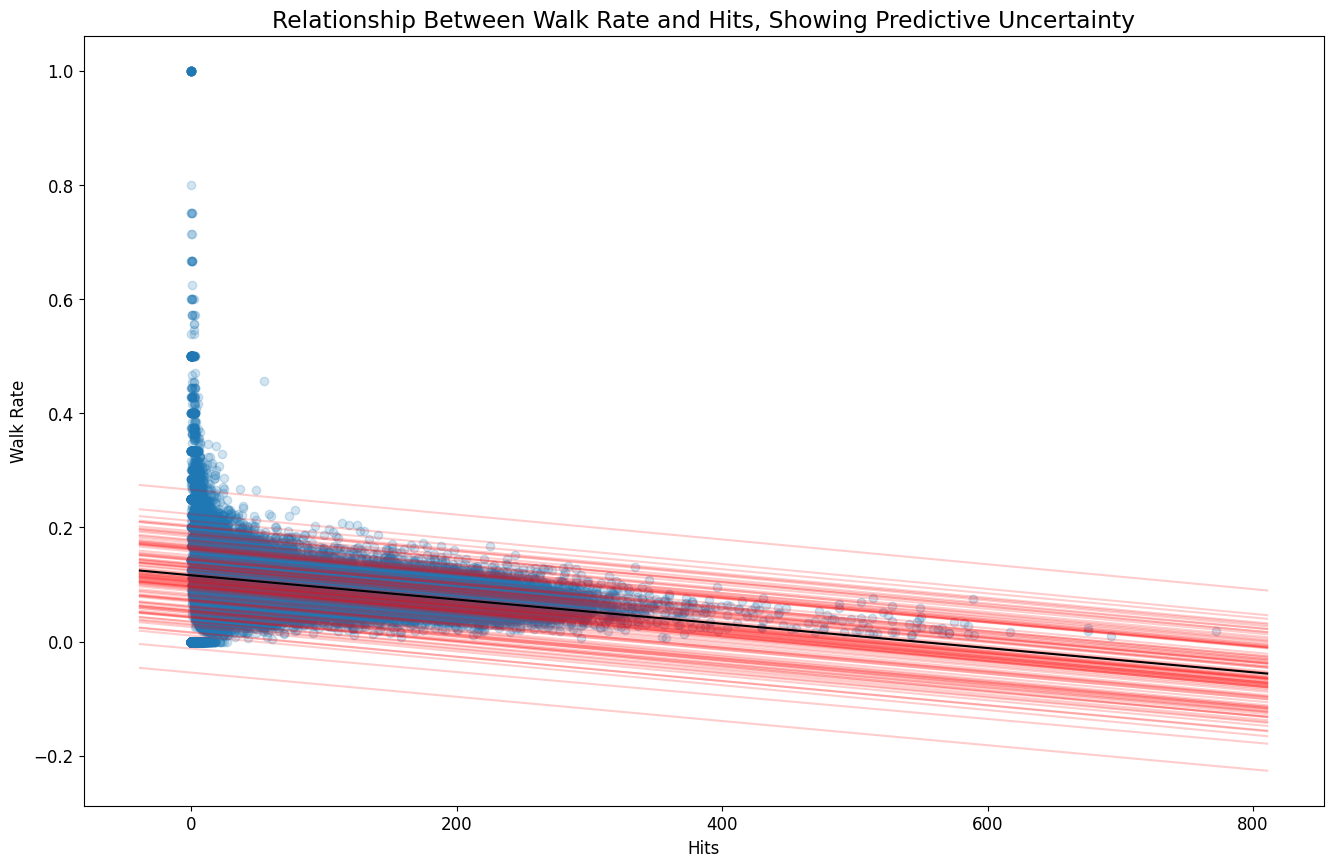

In [42]:
plotSimpleRegWithUncertainty(mod4, pitching_na, 'BBPCT', 'h', 'Walk Rate', 'Hits')

The data shows large variance in walk rate when the number of hits allowed is lower. The uncertainty is also quite sizable. The relationship between hits and walk rate is as expected not really existant.

Next I will see whether there is a relationship between saves and strikeout rate (the frequency that a pitcher strikes out a batter). I would like to see whether a player that saves more often strikes out more batters. Strikeout rate is calculated by:

$SOPCT = \frac{so}{bfp}$

Where **so** is strikeouts and **bfp** is batters faced by pitcher.

In [43]:
pitching['SOPCT'] = pitching['so'] / pitching['bfp']

Like for walk rate, this calculation also results in som infinite values, so I will remove these.

In [44]:
pitching['SOPCT'] = pitching['SOPCT'].replace([np.inf, -np.inf], np.nan)

In [45]:
pitching_na = pitching.dropna(subset = ['SOPCT'])

In [46]:
mod5 = smf.ols('SOPCT ~ sv', data = pitching_na).fit()
mod5.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  SOPCT   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     2421.
Date:                Fri, 15 Dec 2023   Prob (F-statistic):               0.00
Time:                        03:54:43   Log-Likelihood:                 53718.
No. Observations:               41617   AIC:                        -1.074e+05
Df Residuals:                   41615   BIC:                        -1.074e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1275      0.000    373.232      0.000       0.127       0.128
sv             0.0031   6.39e-05     49.207      0.000       0.003       0.003
==============================================================================
Omnibus:                    10620.282   Durbin-Watson:                   1.398
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            74480.979
Skew:                           1.046   Prob(JB):                         0.00
Kurtosis:                       9.211   Cond. No.                         5.61
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Here the $R^2$ is also very low. The coefficient for saves is .003 saying that if a pitcher saves one more game the strikeout rate will be increased by .003 points. 

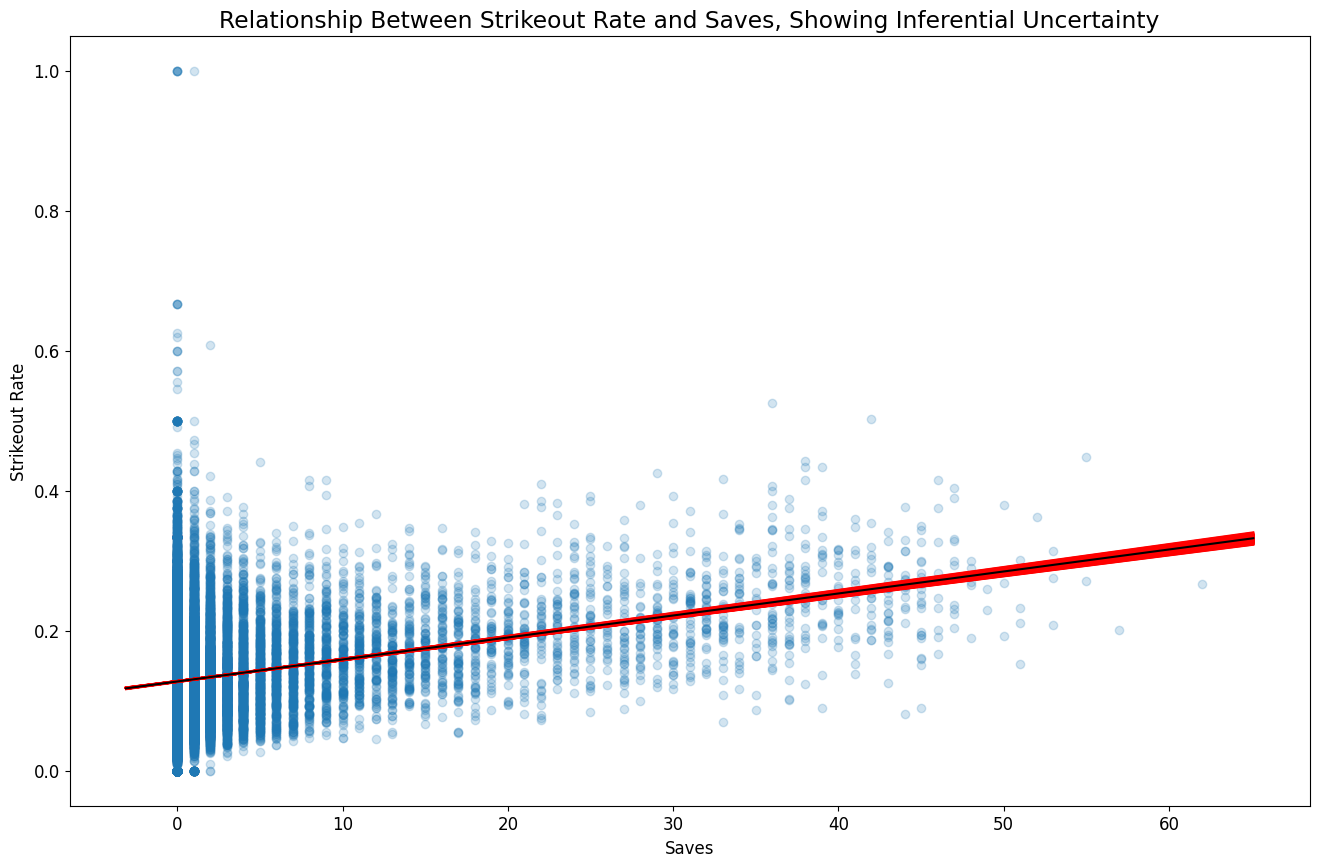

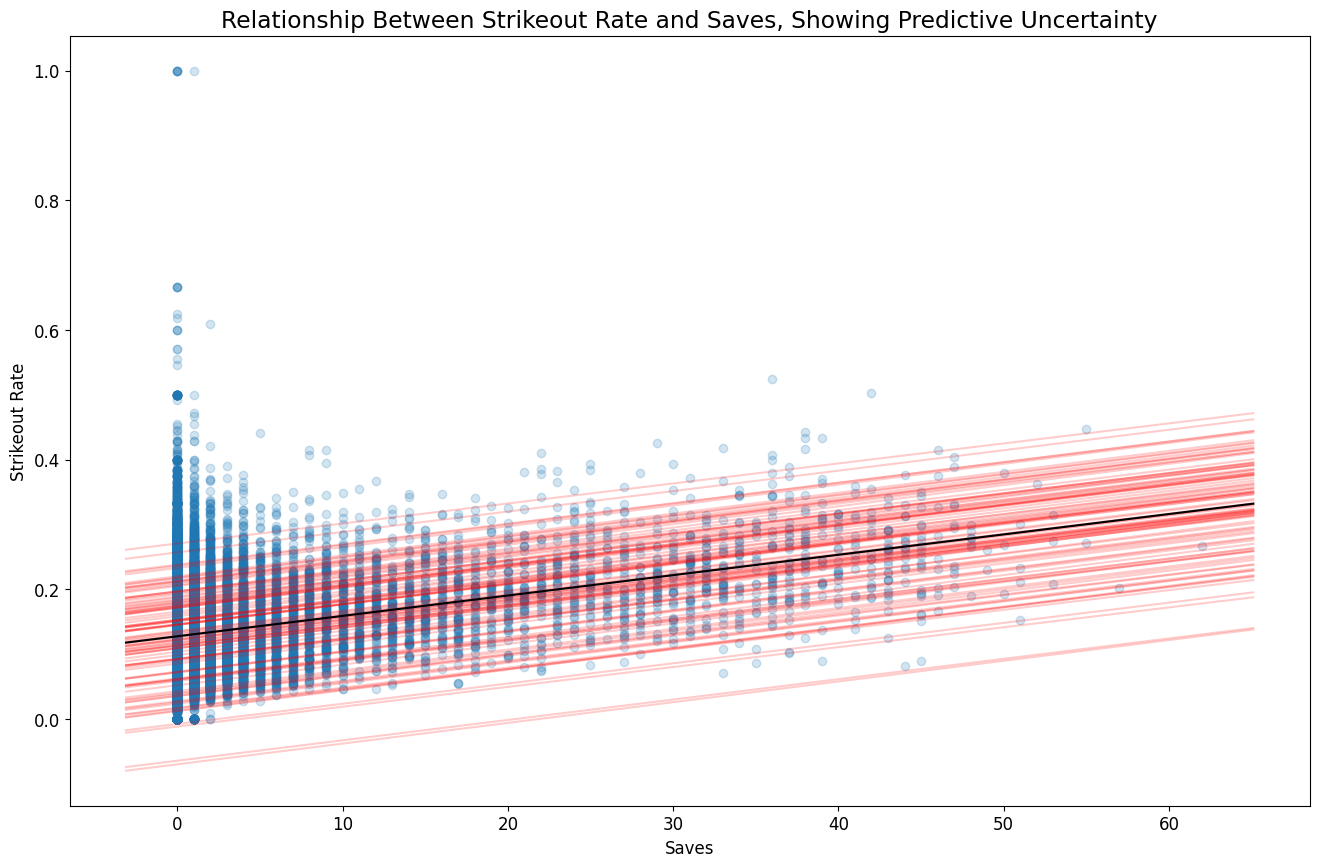

In [47]:
plotSimpleRegWithUncertainty(mod5, pitching_na, 'SOPCT', 'sv', 'Strikeout Rate', 'Saves')

Here there is a lot of variability for the lower values of saves telling me that a pitcher does not save games that often and the strikeout rate still changes quite a lot. There is therefore not an apparent relationship between the amount of times a player saves a game and how much a pitcher strikes out a batter. 

There has been a lot of unsatisfying results with the simple linear regression models modeling relationships between certain factors and central sabermetric statistics. I will now move on to multiple linear regression where multiple independent variables are included to try and explain a dependent variable, hopefully this will provide better, more consistant results. 

### Using Multiple Regression to Attemt to Estimate Player Salary

For multiple linear regression I will try to predict a more complex feature for players, I will be looking at batters' salaries and trying to predict these consistently with several metrics for a batters performance. By doing this I hope to be able to make a model that does the same job as the administrators for a team when desciding how much to pay a player. Before I begin, I do however expect the model not to be very accurate because a big factor in how a player in valuated in monetary worth is the players popularity and previous accomplishments for other teams. There is also limited data to only 30 years between 1985 and 2015, so the sample data probably is not big enough to estimate for all players.

To begin with I will remove missing values from the dataset because I do not have salary information until 1985.

In [48]:
batting_na = batting.dropna(subset = ['adj_salary'])
batting_na.head()

,player_id,year,stint,team_id,league_id,g,ab,r,h,double,triple,hr,rbi,sb,cs,bb,so,hbp,sh,sf,adj_salary,weight,height,bmi,bats,throws,birth_year,age,OBP,AVG
58663,ackerji01,1985,1,TOR,AL,61,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.745853e+05,95.0,1.88,26.9,R,R,1958.0,27.0,NaN,NaN
58665,agostju01,1985,1,CHA,AL,54,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.250078e+05,86.0,1.88,24.3,L,L,1958.0,27.0,NaN,NaN
58666,aguaylu01,1985,1,PHI,NL,91,165.0,27.0,46.0,7.0,3.0,6.0,21.0,1.0,0.0,22.0,26.0,6.0,4.0,3.0,5.222159e+05,78.0,1.75,25.5,R,R,1959.0,26.0,0.377551,0.278788
58669,alexado01,1985,1,TOR,AL,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.928012e+06,86.0,1.90,23.8,R,R,1950.0,35.0,NaN,NaN
58671,allenne01,1985,1,SLN,NL,23,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,1.652582e+06,84.0,1.90,23.3,R,R,1958.0,27.0,0.000000,0.000000


The first model I am creating will include all avaliable variables in the batting dataset.

In [49]:
mod6 = smf.ols('adj_salary ~ g + ab + r + h + double + triple + hr + rbi + sb + cs + bb + so + hbp + sh + sf + weight + height + bmi + age + bats + throws + AVG + OBP', data = batting_na).fit()
mod6.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             adj_salary   R-squared:                       0.305
Model:                            OLS   Adj. R-squared:                  0.304
Method:                 Least Squares   F-statistic:                     351.9
Date:                Fri, 15 Dec 2023   Prob (F-statistic):               0.00
Time:                        03:54:45   Log-Likelihood:            -3.1659e+05
No. Observations:               19244   AIC:                         6.332e+05
Df Residuals:                   19219   BIC:                         6.334e+05
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept   -7.747e+06   8.25e+06     -0.939      0.348   -2.39e+07    8.42e+06
bats[T.L]   -2.749e+05   9.48e+04     -2.899      0.004   -4.61e+05   -8.91e+04
bats[T.R]   -2.869e+05   8.32e+04     -3.447      0.001    -4.5e+05   -1.24e+05
throws[T.R] -4.794e+05   7.98e+04     -6.004      0.000   -6.36e+05   -3.23e+05
g           -3.871e+04   1545.458    -25.048      0.000   -4.17e+04   -3.57e+04
ab           2440.5698   1117.492      2.184      0.029     250.188    4630.951
r            2.095e+04   4746.163      4.414      0.000    1.16e+04    3.03e+04
h            1.874e+04   4174.233      4.491      0.000    1.06e+04    2.69e+04
double      -7975.4742   6973.825     -1.144      0.253   -2.16e+04    5693.832
triple      -1.261e+05   1.81e+04     -6.964      0.000   -1.62e+05   -9.06e+04
hr           7.706e+04   9808.520      7.856      0.000    5.78e+04    9.63e+04
rbi          -105.8732   4426.653     -0.024      0.981   -8782.501    8570.754
sb           3.403e+04   5437.865      6.257      0.000    2.34e+04    4.47e+04
cs          -1.376e+05   1.51e+04     -9.108      0.000   -1.67e+05   -1.08e+05
bb            2.46e+04   2601.660      9.457      0.000    1.95e+04    2.97e+04
so          -4983.4650   1746.850     -2.853      0.004   -8407.444   -1559.486
hbp          4.859e+04   1.05e+04      4.641      0.000    2.81e+04    6.91e+04
sh           9.357e+04   9011.888     10.383      0.000    7.59e+04    1.11e+05
sf          -2.696e+04   1.81e+04     -1.490      0.136   -6.24e+04    8512.021
weight       1.263e+05   4.51e+04      2.800      0.005    3.79e+04    2.15e+05
height      -2.796e+06   4.43e+06     -0.631      0.528   -1.15e+07    5.89e+06
bmi         -2.056e+05   1.57e+05     -1.313      0.189   -5.12e+05    1.01e+05
age          3.714e+05   6123.729     60.652      0.000    3.59e+05    3.83e+05
AVG          2.829e+06      6e+05      4.715      0.000    1.65e+06    4.01e+06
OBP         -4.418e+06   5.51e+05     -8.018      0.000    -5.5e+06   -3.34e+06
==============================================================================
Omnibus:                     8794.256   Durbin-Watson:                   1.871
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            57965.474
Skew:                           2.103   Prob(JB):                         0.00
Kurtosis:                      10.390   Cond. No.                     1.33e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.33e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Already the $R^2$ is better than for the simple models, though not very good. I will now define a new model where I have excluded all variables that seem to be inconsequential, and I will compare the two.

In [50]:
mod7 = smf.ols('adj_salary ~ g + triple + hr + sb + cs + sh + height + bmi + age + bats + throws + AVG + OBP', data = batting_na).fit()
mod7.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             adj_salary   R-squared:                       0.275
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     520.6
Date:                Fri, 15 Dec 2023   Prob (F-statistic):               0.00
Time:                        03:54:45   Log-Likelihood:            -3.1700e+05
No. Observations:               19244   AIC:                         6.340e+05
Df Residuals:                   19229   BIC:                         6.341e+05
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept   -3.035e+07   9.92e+05    -30.597      0.000   -3.23e+07   -2.84e+07
bats[T.L]   -3.209e+05   9.63e+04     -3.331      0.001    -5.1e+05   -1.32e+05
bats[T.R]   -4.071e+05   8.32e+04     -4.893      0.000    -5.7e+05   -2.44e+05
throws[T.R] -3.754e+05   8.11e+04     -4.629      0.000   -5.34e+05   -2.16e+05
g           -1.162e+04    980.819    -11.851      0.000   -1.35e+04   -9701.288
triple       -2.99e+04   1.74e+04     -1.719      0.086    -6.4e+04    4188.451
hr            1.72e+05   4363.634     39.412      0.000    1.63e+05    1.81e+05
sb           6.358e+04   5103.287     12.459      0.000    5.36e+04    7.36e+04
cs          -9.051e+04   1.53e+04     -5.931      0.000    -1.2e+05   -6.06e+04
sh           1.233e+05   8803.763     14.006      0.000    1.06e+05    1.41e+05
height       8.651e+06   4.75e+05     18.215      0.000    7.72e+06    9.58e+06
bmi          2.352e+05   1.06e+04     22.227      0.000    2.14e+05    2.56e+05
age          3.802e+05   6188.638     61.433      0.000    3.68e+05    3.92e+05
AVG          1.732e+06   5.68e+05      3.050      0.002    6.19e+05    2.85e+06
OBP         -2.026e+06   5.19e+05     -3.902      0.000   -3.04e+06   -1.01e+06
==============================================================================
Omnibus:                     8858.935   Durbin-Watson:                   1.872
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            57814.091
Skew:                           2.126   Prob(JB):                         0.00
Kurtosis:                      10.350   Cond. No.                     4.29e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.29e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Based on the $R^2$, this model is actually worse than the first which included all variables. One thing that might improve the results of the model is to do a log transformation on the salary because there is a lot of differences in salary between players. I will perform this log transformation on the original model with all variables because this was inherently better. 

In [51]:
mod61 = smf.ols('np.log(adj_salary) ~ g + ab + r + h + double + triple + hr + rbi + sb + cs + bb + so + hbp + sh + sf + weight + height + bmi + age + bats + throws + AVG + OBP', data = batting_na.loc[(batting_na['adj_salary'] > 0)]).fit()
mod61.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     np.log(adj_salary)   R-squared:                       0.430
Model:                            OLS   Adj. R-squared:                  0.429
Method:                 Least Squares   F-statistic:                     603.9
Date:                Fri, 15 Dec 2023   Prob (F-statistic):               0.00
Time:                        03:54:46   Log-Likelihood:                -27356.
No. Observations:               19243   AIC:                         5.476e+04
Df Residuals:                   19218   BIC:                         5.496e+04
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       1.6460      2.449      0.672      0.502      -3.155       6.447
bats[T.L]      -0.0911      0.028     -3.233      0.001      -0.146      -0.036
bats[T.R]      -0.0888      0.025     -3.593      0.000      -0.137      -0.040
throws[T.R]    -0.1689      0.024     -7.122      0.000      -0.215      -0.122
g              -0.0101      0.000    -22.050      0.000      -0.011      -0.009
ab              0.0017      0.000      5.202      0.000       0.001       0.002
r               0.0040      0.001      2.827      0.005       0.001       0.007
h               0.0039      0.001      3.141      0.002       0.001       0.006
double          0.0026      0.002      1.276      0.202      -0.001       0.007
triple         -0.0246      0.005     -4.571      0.000      -0.035      -0.014
hr              0.0209      0.003      7.162      0.000       0.015       0.027
rbi            -0.0011      0.001     -0.873      0.382      -0.004       0.001
sb              0.0107      0.002      6.636      0.000       0.008       0.014
cs             -0.0326      0.004     -7.268      0.000      -0.041      -0.024
bb              0.0067      0.001      8.614      0.000       0.005       0.008
so             -0.0021      0.001     -4.051      0.000      -0.003      -0.001
hbp             0.0083      0.003      2.684      0.007       0.002       0.014
sh              0.0406      0.003     15.160      0.000       0.035       0.046
sf              0.0058      0.005      1.080      0.280      -0.005       0.016
weight          0.0032      0.013      0.241      0.809      -0.023       0.029
height          2.9815      1.315      2.267      0.023       0.403       5.560
bmi             0.0672      0.046      1.444      0.149      -0.024       0.158
age             0.1695      0.002     93.210      0.000       0.166       0.173
AVG             1.0050      0.178      5.640      0.000       0.656       1.354
OBP            -1.7377      0.164    -10.619      0.000      -2.059      -1.417
==============================================================================
Omnibus:                      373.171   Durbin-Watson:                   1.781
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              391.471
Skew:                           0.343   Prob(JB):                     9.84e-86
Kurtosis:                       2.870   Cond. No.                     1.33e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.33e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The log transformation did indeed improve the results of the model, though still not great, the $R^2$ has improved. I am also looking at the AIC (Akaike Information Criterion) and BIC (Bayes Information Criterion) which are metrics to be used to compare multiple models, the magnitude of these metrics are not consequential, but the model with the smallest information criterion is the better one. In this case both information criterion are an order of magnitude smaller for the log transformed model than for the others, which says that it is objectivly better. 

To further evaluate this model I will graph its fitted (predicted) values againt its residuals to assess the goodness of its fit. For this plot I would like to see a random scatter of residuals around the horizontal axis without any discernable patterns, this would indicate constant variance for all fitted values. 

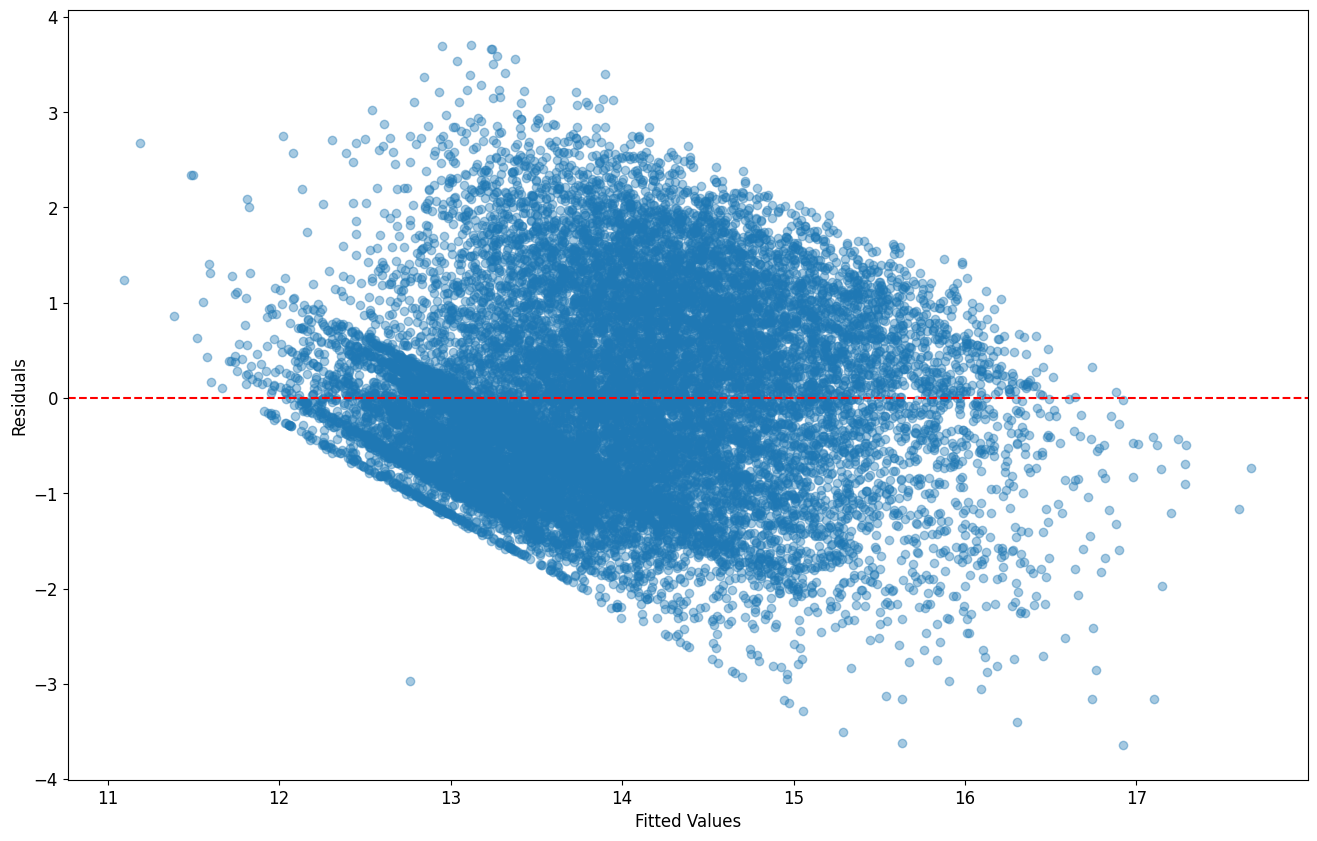

In [52]:
predicted = mod61.fittedvalues
residuals = mod61.resid

fig, ax = plt.subplots()
ax.scatter(predicted, residuals, alpha = .4)
ax.axhline(0, color = 'red', ls = '--')
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residuals')
plt.show()

As you can see, there is definitly a pattern here. The points are not randomly scattered around the horizontal axis (here displayed by a red dashed line), instead they follow a linear pattern down toward the right indicating that the model is not very good. I can also identify a lot of outliers, most in the wake of the obvious pattern, but also one in particular in the lower left of the figure. 

### Determining Whether a Team Will Win the World Series or Not

In this part of the project I will be trying to make a model which can predict whether or not a team might win the world series based on an exploratory variable. I will be doing this by means of logistic regression, which is a statistical method used to model the probability of an event occurring. The logistic regression does a non-linear transformation of the data to make the fitted values between 0 and 1. For this reason logistic regression is optimal for problems with binary outcomes, where the dependent variable can either be one of two possible options, in this case yes or no. The non-linear transformation is performed with what is called the inverse logit function:

$invlogit(x) = \frac{e^x}{1 - e^x}$

I will be using this function for plotting the results of the logistic regression as defined below. I will also be using the **logSim** function that was devised in the labs as seen below.

In [53]:
def invLogit(x):
    return np.exp(x) / (1 + np.exp(x))

In [54]:
def logSim(regMod): 
    # Extract values from regression model.
    nmk = regMod.df_resid
    bs_vcov = regMod.cov_params()
    bs = regMod.params
    
    # Create simulated values.
    V_sim = np.array(bs_vcov) * np.sqrt(nmk / np.random.chisquare(nmk, 1))
    bs_sim = np.random.multivariate_normal(bs, V_sim, 1)
    
    return bs_sim.flatten()

There are some missing values in the data for whether or not a team won the world series so I remove these.

In [55]:
team_na = team.dropna(subset = ['ws_win'])

These are also labeled as 'Y' for yes and 'N' for no, so I recreate it as a dummy variable with 1 being yes and 0 being no. 

In [56]:
team_na = pd.get_dummies(team_na, columns = ['ws_win'], drop_first = True, dtype = int)

Now I can define the logistic regression with runs being the independent variable. I think this could be a good explanatory variable because in baseball points are gained by scoring runs, and I imagine that a team with more points than others have a better chance of winning championships. If a team has more runs than others, this could mean that they are more consistant and that they have a better team overall and thereby have a better chance of winning the world series.

In reference to the definition of the model, I now using the Generalized Linear Model (GLM) method for fitting the model, this method uses maximum likelyhood for estimating coefficients. Maximum likelyhood works by maximizing the likelyhood function, for binary outcomes this function is the product of the probabilities of observing each outcome with the assumption of independence. 

In [57]:
mod7 = smf.glm('ws_win_Y ~ r', data = team_na, family = sm.families.Binomial()).fit()
mod7.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:               ws_win_Y   No. Observations:                 2386
Model:                            GLM   Df Residuals:                     2384
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -427.51
Date:                Fri, 15 Dec 2023   Deviance:                       855.01
Time:                        03:54:47   Pearson chi2:                 2.49e+03
No. Iterations:                     7   Pseudo R-squ. (CS):            0.02761
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -8.3472      0.712    -11.729      0.000      -9.742      -6.952
r              0.0073      0.001      7.979      0.000       0.006       0.009
==============================================================================
"""

In [58]:
N = team_na.shape[0]

For visualizing the data better with the logistic regression line, I am adding some jitter to the data.

In [59]:
runs_j = team_na['r'] + spt.uniform(-.25, .5).rvs(size = N)
wswin_j = team_na['ws_win_Y'] + spt.uniform(-.05, .1).rvs(size = N)

Below I am extracting the parameters from the regression and defining the line with the inverse logit function. 

In [60]:
a_hat = mod7.params.iloc[0]
b_hat = mod7.params.iloc[1]

x = np.linspace(300, 1200, N)
y_line = invLogit(a_hat + b_hat * x)

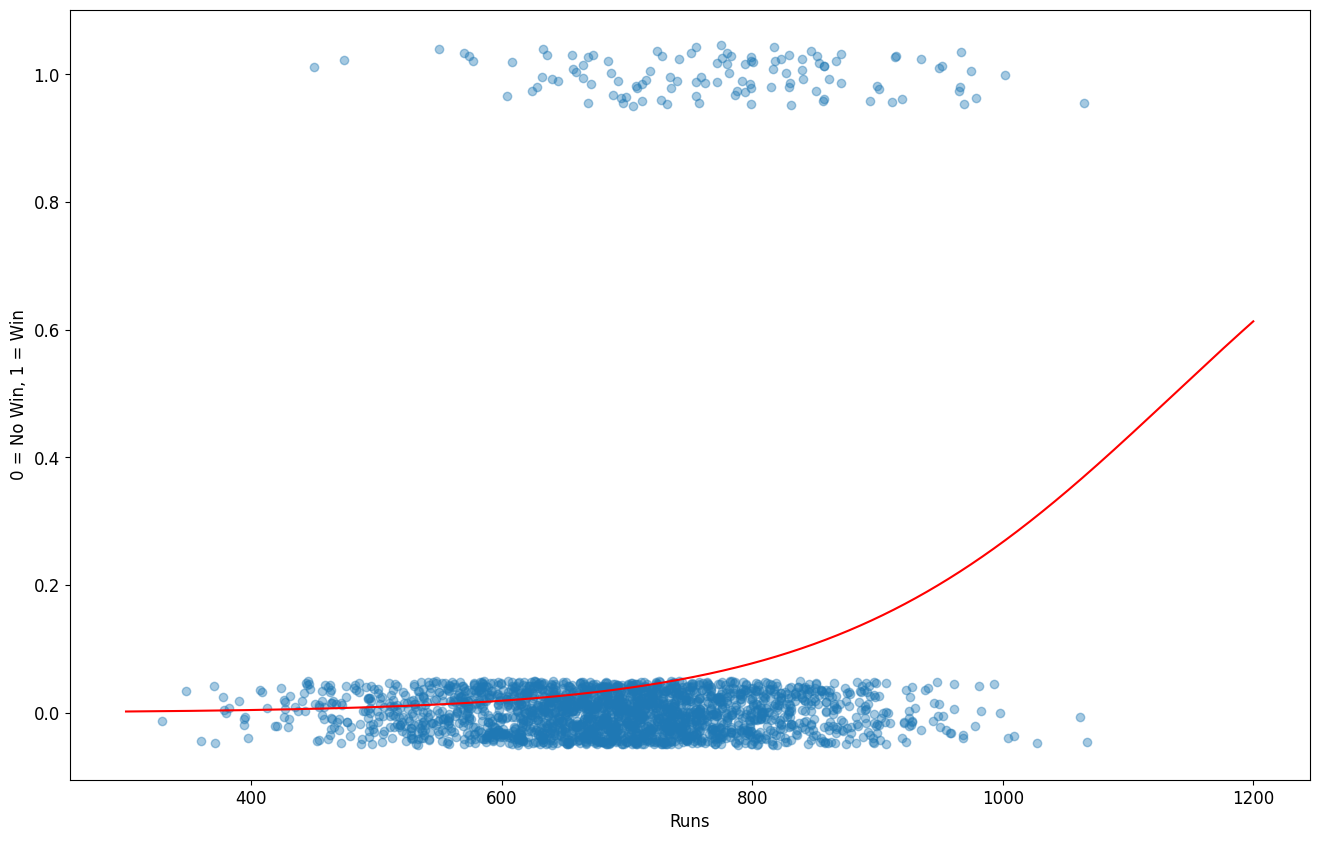

In [61]:
fig, ax = plt.subplots()
ax.scatter(runs_j, wswin_j, alpha = .4)
ax.plot(x, y_line, color = 'red')
ax.set_xlabel('Runs')
ax.set_ylabel('0 = No Win, 1 = Win')
plt.show()

From this plot I can see that it does indeed seem like teams with more runs, more often win the world series. There are however still a lot of teams who have more runs than the teams who actually won the world series, and some teams who won the world series have quite few runs compared to others. So runs might not be the best predictor, though good. The probability for winning the world series will be quite low even for a higher number of runs.

I will now simulate the uncertainty of the model using the **logSim** function.

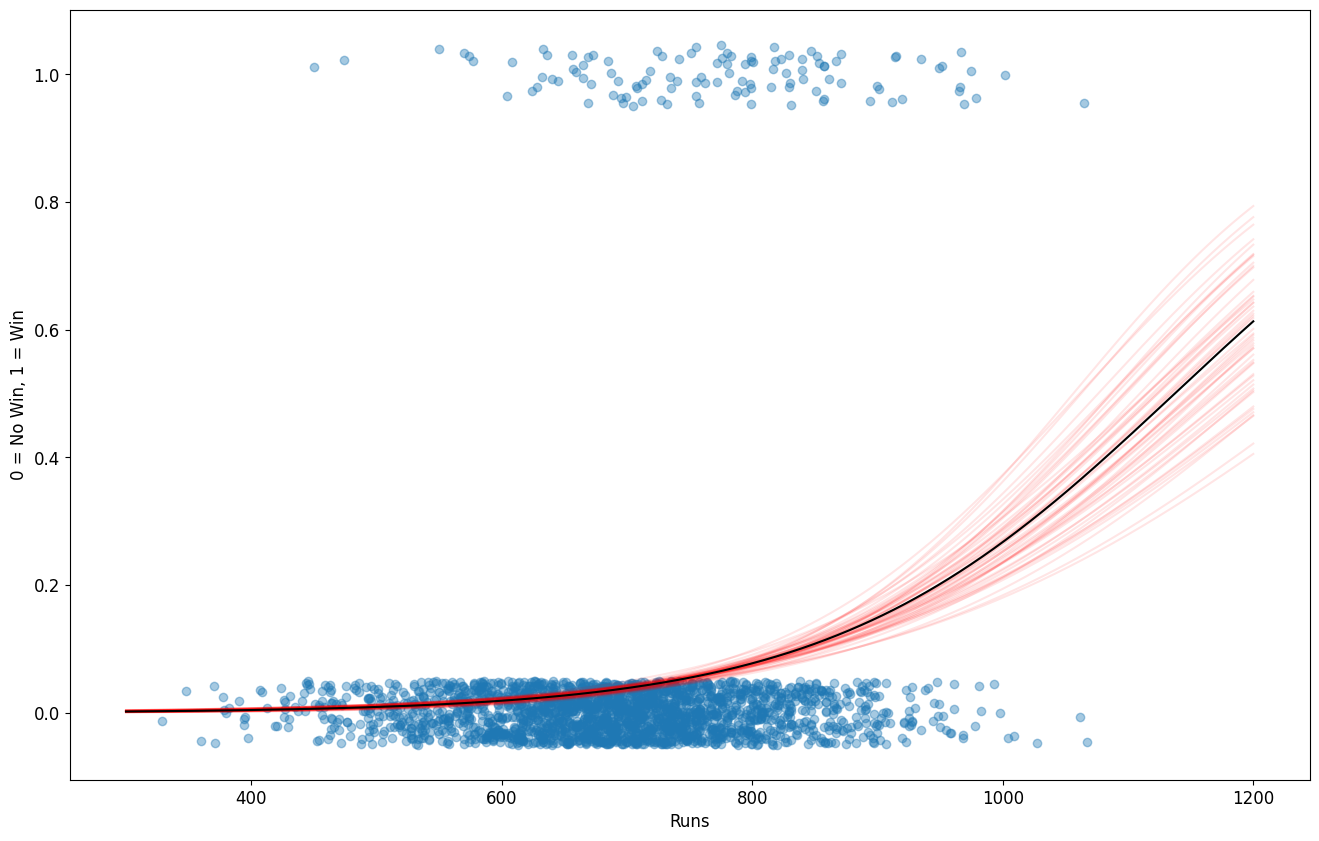

In [62]:
nsims = 50
bs_sims = []

for s in range(nsims):
    bs_sim = logSim(mod7)
    bs_sims.append(bs_sim)

fig, ax = plt.subplots()
ax.scatter(runs_j, wswin_j, alpha = .4)
ax.plot(x, y_line, color = 'black', zorder = 10)

for i in range(nsims):
    y_line_sim = invLogit(bs_sims[i][0] + bs_sims[i][1] * x)
    ax.plot(x, y_line_sim, color = 'red', alpha = .1)

ax.set_xlabel('Runs')
ax.set_ylabel('0 = No Win, 1 = Win')
plt.show()

For this next model I will use the position the team finished in in the division championship to try and predict whether the team will win the world series. I expect only the teams in the higher ranks to have won the championship because only the best teams for each division will have the chance to go to the world series. I also expect that there will be more teams in the higher ranks that have won the world series because a team that does better in the division series can be expected to perform better in the playoffs.

In [63]:
mod8 = smf.glm('ws_win_Y ~ rank', data = team_na, family = sm.families.Binomial()).fit()
mod8.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:               ws_win_Y   No. Observations:                 2386
Model:                            GLM   Df Residuals:                     2384
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -256.04
Date:                Fri, 15 Dec 2023   Deviance:                       512.08
Time:                        03:54:48   Pearson chi2:                     768.
No. Iterations:                    11   Pseudo R-squ. (CS):             0.1578
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.3307      0.427      5.463      0.000       1.495       3.167
rank          -3.1861      0.380     -8.375      0.000      -3.932      -2.440
==============================================================================
"""

Adding jitter to the data.

In [64]:
rank_j = team_na['rank'] + spt.uniform(-.25, .5).rvs(size = N)

Extracting the model parameters and defining the regression line.

In [65]:
a_hat = mod8.params.iloc[0]
b_hat = mod8.params.iloc[1]

x = np.linspace(.5, 10, N)
y_line = invLogit(a_hat + b_hat * x)

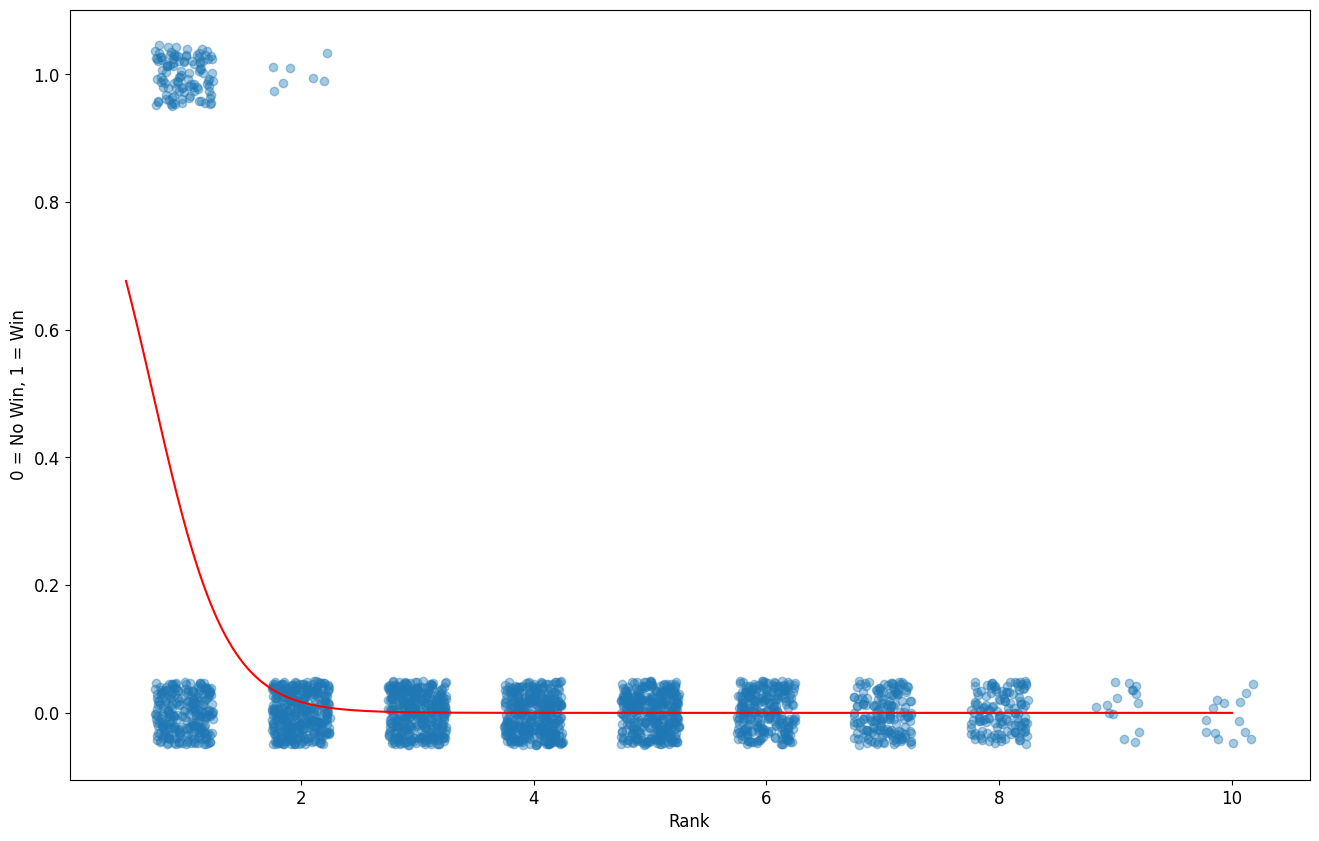

In [66]:
fig, ax = plt.subplots()
ax.scatter(rank_j, wswin_j, alpha = .4)
ax.plot(x, y_line, color = 'red')
ax.set_xlabel('Rank')
ax.set_ylabel('0 = No Win, 1 = Win')
plt.show()

As expected, only teams in the higher ranks have won the world series, and there were more teams from the higher rank than the lower that won. I did however expect a few teams from the thrid and fourth rank to also have won, but I digress. The regression line is fitted as you would expect, there are a lot of teams who have gotten the first rank in the division series who have not won the world series (which makes sense because only one team can win the world series, but there are six division series) so the probability for a team to win the world series when they are rank one or rank two will be quite low. 

Simulating the uncertainty.

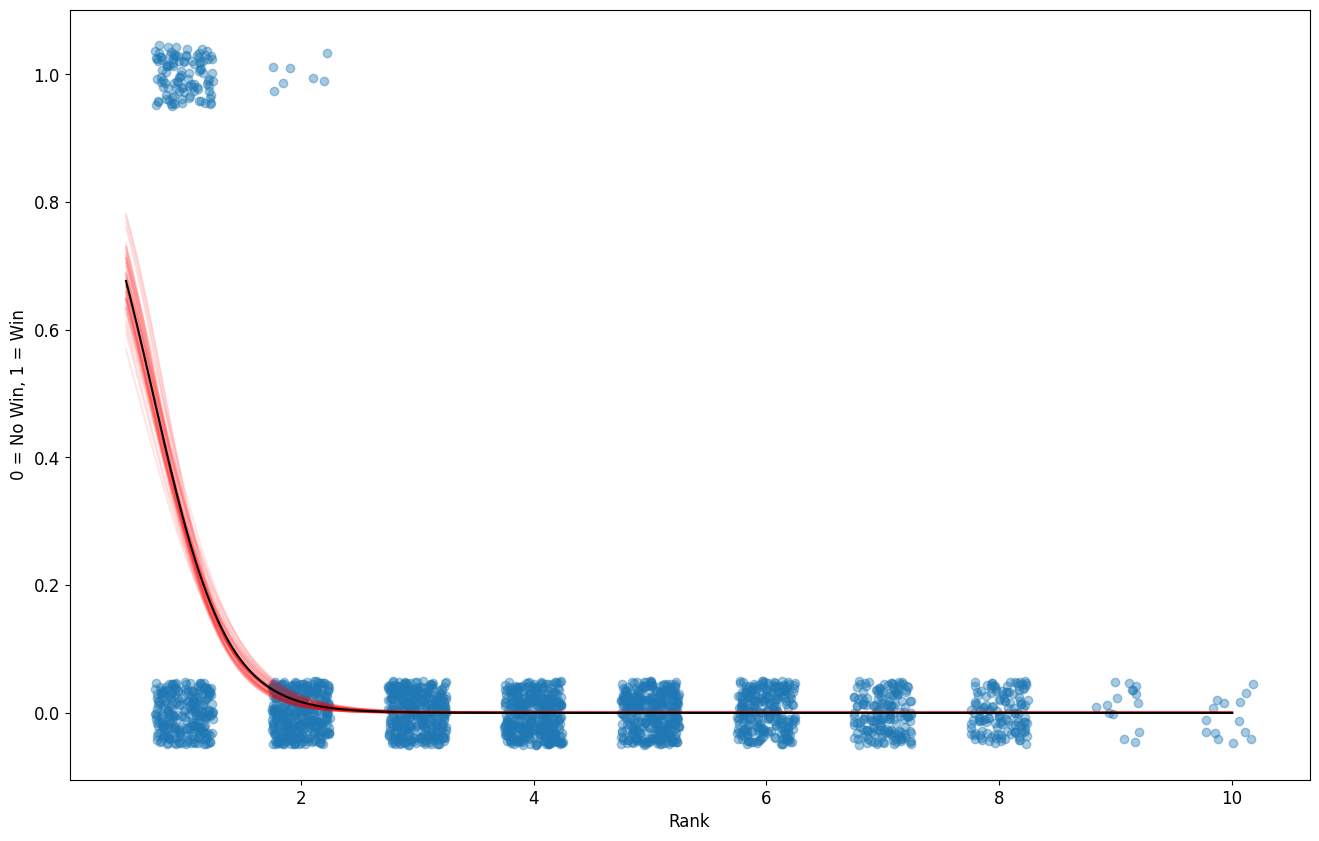

In [67]:
bs_sims = []

for s in range(nsims):
    bs_sim = logSim(mod8)
    bs_sims.append(bs_sim)

fig, ax = plt.subplots()
ax.scatter(rank_j, wswin_j, alpha = .4)
ax.plot(x, y_line, color = 'black', zorder = 10)

for i in range(nsims):
    y_line_sim = invLogit(bs_sims[i][0] + bs_sims[i][1] * x)
    ax.plot(x, y_line_sim, color = 'red', alpha = .1)

ax.set_xlabel('Rank')
ax.set_ylabel('0 = No Win, 1 = Win')
plt.show()

### Conclusions

In this project I have performed some exploratory analysis to get a deeper understanding of the relationships hidden in the data. I have used simple linear regression to attempt to find some relationships between advanced sabermetrics and player performance, unfortunately with dissappointing results. I have used multiple linear regression to try to do the job of team administrators of assinging a player a salary based on their performance, and I have created models which can assign a team a probability for winning the world series based on some of their performance statistics, all while keeping model validity and uncertainty in mind. 

This project did not have one singular problem to solve, instead I wanted to use this opportunity to delve more deeply into a sport I have known my whole life. I wanted learn how different measures for player and team performance relates to each other (and those who do not) with the statistical tools I have gained throughout this semester, and I believe I have been able to unveil some hidden relationships in the data. Sabermetrics and more generally, sports analytics is a very complex and complicated realm of statistics, and though I have looked at some of the more central aspects, I have only scratched the surface. Because of the limited scope of this project, I have not been able to go as deep as I might have wanted, but I believe I have highlighted how interesting sports analytics can be, through the lens of sabermetrics. 

### Sources

Data:
- Lahman Baseball Database: https://www.kaggle.com/datasets/seanlahman/the-history-of-baseball
- Lahman Database Documentation: https://cran.r-project.org/web/packages/Lahman/Lahman.pdf
- CPI Data: https://www.kaggle.com/datasets/neelgajare/usa-cpi-inflation-from-19132022

Calculations:
- Advanced baseball metrics: https://www.mlb.com/glossary/advanced-stats
- Standard baseball metrics: https://www.mlb.com/glossary/standard-stats
- Inflation adjustment formula: https://study.com/academy/lesson/adjusting-wages-for-the-inflation-rate.html#:~:text=There%20are%20two%20main%20formulas,CPI%20in%20the%20selected%20year
- BMI formula: https://www.calculatorsoup.com/calculators/health/bmi-calculator.php

General Information:
- The Labs (code and theory)
- General baseball information: https://www.britannica.com/sports/baseball/Awards